# Tesis - MDM UBA - 2026

**Tariff classification using NLP**

By Santiago Tedoldi

# Error analysis

In [46]:
# Dependencies
import os
import math
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import re
from typing import Dict, List, Optional, Tuple

import seaborn as sns


## Utils

In [3]:
def plot_numeric_distributions_filter_vs_complement(
    df: pd.DataFrame,
    mask: pd.Series | np.ndarray,
    columns: list[str],
    bins: int = 30,
    density: bool = True,
    figsize_per_plot: tuple[float, float] = (8, 3.8),
    alpha_fill: float = 0.28,
    linewidth: float = 2.2,
    clip_01: bool = True,
    normalize_mask_index: bool = True,
    label_filter: str = "Filtro",
    label_complement: str = "Complemento",
    title_prefix: str | None = None,
    gray_mask: str = "#7f7f7f",
):
    """
    Grafica distribuciones de variables numéricas comparando:
      - df[mask]
      - df[~mask]

    Diseño:
      - 1 sola columna de subplots
      - mismo color gris para la máscara
      - un color distinto para el complemento en cada variable
    """

    if not isinstance(df, pd.DataFrame):
        raise TypeError("df debe ser un pandas DataFrame.")

    if not columns:
        raise ValueError("Debes pasar al menos una columna en `columns`.")

    missing_cols = [c for c in columns if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Columnas inexistentes en df: {missing_cols}")

    # --- máscara ---
    if isinstance(mask, np.ndarray):
        if mask.dtype != bool:
            raise TypeError("Si mask es np.ndarray, debe ser booleana.")
        if len(mask) != len(df):
            raise ValueError("Si mask es np.ndarray, debe tener el mismo largo que df.")
        mask = pd.Series(mask, index=df.index)

    elif isinstance(mask, pd.Series):
        if mask.dtype != bool:
            raise TypeError("Si mask es pd.Series, debe ser booleana.")
        if normalize_mask_index:
            mask = mask.reindex(df.index, fill_value=False)
        elif not mask.index.equals(df.index):
            raise ValueError(
                "El índice de mask no coincide con el de df. "
                "Usá normalize_mask_index=True para reindexar."
            )
    else:
        raise TypeError("mask debe ser pd.Series o np.ndarray booleano.")

    df_filter = df.loc[mask].copy()
    df_complement = df.loc[~mask].copy()

    if df_filter.empty:
        raise ValueError("La población definida por `mask` está vacía.")
    if df_complement.empty:
        raise ValueError("El complemento de `mask` está vacío.")

    n_plots = len(columns)
    fig, axes = plt.subplots(
        n_plots,
        1,
        figsize=(figsize_per_plot[0], figsize_per_plot[1] * n_plots),
        sharex=False,
        sharey=False,
    )

    if n_plots == 1:
        axes = [axes]

    # paleta para el complemento: un color distinto por subplot
    cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
    if not cycle:
        cycle = ["C0", "C1", "C2", "C3", "C4", "C5"]

    for i, (ax, col) in enumerate(zip(axes, columns)):
        s_filter = pd.to_numeric(df_filter[col], errors="coerce").dropna()
        s_comp = pd.to_numeric(df_complement[col], errors="coerce").dropna()

        if s_filter.empty or s_comp.empty:
            ax.set_title(f"{col} (sin datos suficientes)")
            ax.axis("off")
            continue

        if clip_01:
            edges = np.linspace(0.0, 1.0, bins + 1)
        else:
            col_min = min(s_filter.min(), s_comp.min())
            col_max = max(s_filter.max(), s_comp.max())
            if col_min == col_max:
                col_min -= 1e-6
                col_max += 1e-6
            edges = np.linspace(col_min, col_max, bins + 1)

        hist_filter, edges = np.histogram(s_filter, bins=edges, density=density)
        hist_comp, _ = np.histogram(s_comp, bins=edges, density=density)

        centers = (edges[:-1] + edges[1:]) / 2

        comp_color = cycle[i % len(cycle)]

        # máscara en gris
        ax.plot(
            centers,
            hist_filter,
            linewidth=linewidth,
            color=gray_mask,
            label=f"{label_filter} (n={len(s_filter)})",
            zorder=3,
        )
        ax.fill_between(
            centers,
            0,
            hist_filter,
            color=gray_mask,
            alpha=alpha_fill,
            zorder=1,
        )

        # complemento con color distinto por variable
        ax.plot(
            centers,
            hist_comp,
            linewidth=linewidth,
            color=comp_color,
            label=f"{label_complement} (n={len(s_comp)})",
            zorder=3,
        )
        ax.fill_between(
            centers,
            0,
            hist_comp,
            color=comp_color,
            alpha=alpha_fill,
            zorder=1,
        )

        title = f"{title_prefix} - {col}" if title_prefix else col
        ax.set_title(title)
        ax.set_xlabel(col)
        ax.set_ylabel("Densidad" if density else "Frecuencia relativa")
        ax.grid(True, alpha=0.25)

        if clip_01:
            ax.set_xlim(0, 1)

        ymax = max(
            float(np.max(hist_filter)) if len(hist_filter) else 0.0,
            float(np.max(hist_comp)) if len(hist_comp) else 0.0,
        )
        pad = 0.05 * ymax if ymax > 0 else 0.05
        ax.set_ylim(0, ymax + pad)

        ax.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

## Test sample

Loading model training config

In [4]:
with open('results/distilbert/fft_final/final_model/training_config.json', 'r') as file:
    # The json.load() function reads the file and returns a Python object
    model_cofig = json.load(file)

with open('results/distilbert/fft_final/labels/labels_dict_FINAL_DBERT_fft_GOODS_DESCRIPTION_HS04_seed32.json', 'r') as file:
    # The json.load() function reads the file and returns a Python object
    labels_dict = json.load(file)

label2id = labels_dict["label2id"]
id2label = labels_dict["id2label"]
id2label = {int(k): v for k, v in id2label.items()}

model_cofig

{'run_name': 'FINAL_DBERT_fft_GOODS_DESCRIPTION_HS04_seed32',
 'train_type': 'fft',
 'text_col': 'GOODS_DESCRIPTION',
 'target_col': 'HS04',
 'max_length': 300,
 'batch_size': 128,
 'lr': 5e-05,
 'test_fraction': 0.01,
 'seed': 32,
 'max_epochs': 5,
 'early_stopping': True,
 'monitor': 'val_loss',
 'patience': 3,
 'min_delta': 0.0,
 'warmup_epochs': 1,
 'fine_tune': True,
 'n_finetune_layers': 0}

### Test dataset with inference

In [5]:
data_type = {'Description': str,
             'True Label': str,
             'Top1': str,
             'Top2': str,
             'Top3': str,
             'Top4': str,
             'Top5': str,
             }

test = pd.read_csv('results/distilbert/fft_final/final_val_predictions.csv', index_col=0,
                   dtype=data_type)
test.head()

,Description,True Label,Top1,Proba Top1,Top2,Proba Top2,Top3,Proba Top3,Top4,Proba Top4,Top5,Proba Top5
354196,sterilizing cabinet,8419,9402,0.265925,9403,0.247374,9018,0.227738,8419,0.099247,8537,0.027063
155635,PERFUMES-LOVE INTETION,3303,3303,0.942016,3307,0.036050,3302,0.015176,3301,0.001438,3304,0.000576
134060,High voltage insulating tape,3920,8546,0.445084,3919,0.234640,5906,0.089700,3920,0.048213,3921,0.029814
114018,BEARING 6805 ZZ BRAND KG,8482,8482,0.995477,8483,0.000293,7319,0.000043,8711,0.000042,7009,0.000021
264869,USED SOFA 3SEATER,9403,9403,0.621796,9401,0.366761,9404,0.001297,8715,0.000630,9402,0.000514


In [6]:
len(test['True Label'].unique())

507

Top1 = True Label 

In [7]:
test.loc[test['True Label'] == test['Top1']]

,Description,True Label,Top1,Proba Top1,Top2,Proba Top2,Top3,Proba Top3,Top4,Proba Top4,Top5,Proba Top5
155635,PERFUMES-LOVE INTETION,3303,3303,0.942016,3307,0.036050,3302,0.015176,3301,0.001438,3304,0.000576
114018,BEARING 6805 ZZ BRAND KG,8482,8482,0.995477,8483,0.000293,7319,0.000043,8711,0.000042,7009,0.000021
264869,USED SOFA 3SEATER,9403,9403,0.621796,9401,0.366761,9404,0.001297,8715,0.000630,9402,0.000514
288332,A9060530008 VALVE CAP (MERCEDES 3029 TRUCK SPA...,8481,8481,0.478391,8409,0.389589,8431,0.017505,8414,0.017504,8708,0.011795
194485,LS MAXI DRESS-CREAM,6204,6204,0.856333,6104,0.118773,6209,0.006772,6114,0.004677,6108,0.002718
...,...,...,...,...,...,...,...,...,...,...,...,...
60591,MECHANICAL SPARE PARTS : 1-018-45-166-0 FILTER,8421,8421,0.827260,8481,0.010940,8413,0.010221,8414,0.008333,9026,0.008277
134710,The supercharger,8414,8414,0.964030,8409,0.022942,8708,0.002072,8803,0.001035,8431,0.001012
59522,"WASHER, FLAT: NOMINAL SIZE: M22; MATERIAL: STEEL",7318,7318,0.981964,7415,0.015497,8450,0.000313,4016,0.000112,7320,0.000092
98085,AIR FILTER MATERIALS,8421,8421,0.995164,5911,0.000568,9002,0.000530,7019,0.000445,4823,0.000151


In [8]:
test.loc[test['True Label'] == test['Top1']].head(10).to_clipboard(index=False, excel=True)

Top1 != True Label 

In [9]:
test.loc[test['True Label'] != test['Top1']]

,Description,True Label,Top1,Proba Top1,Top2,Proba Top2,Top3,Proba Top3,Top4,Proba Top4,Top5,Proba Top5
354196,sterilizing cabinet,8419,9402,0.265925,9403,0.247374,9018,0.227738,8419,0.099247,8537,0.027063
134060,High voltage insulating tape,3920,8546,0.445084,3919,0.234640,5906,0.089700,3920,0.048213,3921,0.029814
241378,FLAME TREATMNET MACHINE,8419,8479,0.286222,8438,0.205112,8419,0.085045,8515,0.078899,8477,0.053334
326349,1538921 PIPE,7306,8409,0.306786,7304,0.172320,8708,0.143968,4009,0.080440,7306,0.058872
169992,250UL FOR 1 LIQUID IN-LINE MIXER,8421,8479,0.924689,8474,0.022249,8438,0.004382,9018,0.002613,7017,0.002440
...,...,...,...,...,...,...,...,...,...,...,...,...
43590,BUSHIBG,8484,8483,0.457826,8708,0.128096,7318,0.084860,4016,0.048190,8431,0.041487
330222,TP G CRAMP 1261 -4in,8205,7326,0.509213,7318,0.111137,7308,0.080971,8205,0.051209,7307,0.025811
175244,LOCK FOR EXCAVATOR,8431,8301,0.493903,8431,0.425624,7318,0.018716,8708,0.013164,8483,0.005661
2697,ZEOLITH UNIT E080 AUTOTROL (2PCS),3006,3824,0.644254,3006,0.083513,3808,0.023826,3822,0.017465,3506,0.015863


In [10]:
test.loc[test['True Label'] != test['Top1']].head(10).to_clipboard(index=False, excel=True)

In [11]:
test.loc[test['True Label'] != test['Top1']].sort_values(by='Proba Top1', ascending=False).head(5)

,Description,True Label,Top1,Proba Top1,Top2,Proba Top2,Top3,Proba Top3,Top4,Proba Top4,Top5,Proba Top5
121297,PISTON (SPARE PARTS FOR DIESEL ALTERNATOR; 124...,8413,8409,0.995157,8431,0.001266,8414,0.000579,8413,0.000434,8412,0.000430
246765,"HANDKERCHIEF, BRAND: ROSE,MODEL: 36749",5802,6213,0.995027,6310,0.000763,6117,0.000561,6217,0.000172,4813,0.000165
373916,PRESIDENT CAMEMBERT 12X145G,0403,0406,0.991559,2101,0.001314,1904,0.001281,1806,0.001248,2208,0.000786
186890,USED SCANIA TIPPERS,8701,8704,0.991293,8701,0.002539,8705,0.000914,8702,0.000814,8429,0.000249
146,"THERMAL PRINTER,SEIKO-PART NO.LTP01-245-11",8473,8443,0.989610,8422,0.003666,8442,0.000639,8477,0.000617,8472,0.000314


In [12]:
test.loc[test['True Label'] != test['Top1']].sort_values(by='Proba Top1', ascending=False).head(5).to_clipboard(index=False, excel=True)

In [13]:
test.loc[test['True Label'] != test['Top1']].sort_values(by='Proba Top1', ascending=True).head(5)

,Description,True Label,Top1,Proba Top1,Top2,Proba Top2,Top3,Proba Top3,Top4,Proba Top4,Top5,Proba Top5
64927,FGP - 48,3707,3811,0.024027,3824,0.020048,3907,0.019762,3506,0.019288,3215,0.019041
436501,COLGANTE DE CUERO,7117,6204,0.028127,2103,0.025122,6907,0.023948,8509,0.020929,8516,0.020739
172847,CABAS,4202,6203,0.032557,2710,0.028059,8544,0.026146,8714,0.025611,6114,0.019470
275993,BUCKECTS,6911,9506,0.043034,7318,0.033153,9403,0.032755,6304,0.028558,3926,0.025739
271589,SOULDER,6217,8421,0.043645,8714,0.032469,3808,0.031463,7323,0.028452,8516,0.025421


In [14]:
test.loc[test['True Label'] != test['Top1']].sort_values(by='Proba Top1', ascending=True).head(5).to_clipboard(index=False, excel=True)

Errors Top1 to Top5

In [15]:
error = (
    (test['True Label'] != test['Top1']) &
    (test['True Label'] != test['Top2']) &
    (test['True Label'] != test['Top3']) &
    (test['True Label'] != test['Top4']) &
    (test['True Label'] != test['Top5'])
)

In [16]:
test.loc[error].sort_values(by='Proba Top1', ascending=False).head(5)

,Description,True Label,Top1,Proba Top1,Top2,Proba Top2,Top3,Proba Top3,Top4,Proba Top4,Top5,Proba Top5
246765,"HANDKERCHIEF, BRAND: ROSE,MODEL: 36749",5802,6213,0.995027,6310,0.000763,6117,0.000561,6217,0.000172,4813,0.000165
373916,PRESIDENT CAMEMBERT 12X145G,0403,0406,0.991559,2101,0.001314,1904,0.001281,1806,0.001248,2208,0.000786
146,"THERMAL PRINTER,SEIKO-PART NO.LTP01-245-11",8473,8443,0.989610,8422,0.003666,8442,0.000639,8477,0.000617,8472,0.000314
438300,TALCUM PEN,3304,9608,0.985763,9609,0.005200,3926,0.000967,6804,0.000766,8207,0.000393
295224,CUSTOMIZED NOTE BOOK,4821,4820,0.984234,4911,0.003227,4909,0.001866,4819,0.001688,3926,0.001467


In [17]:
test.loc[error].sort_values(by='Proba Top1', ascending=False).tail(5)

,Description,True Label,Top1,Proba Top1,Top2,Proba Top2,Top3,Proba Top3,Top4,Proba Top4,Top5,Proba Top5
271589,SOULDER,6217,8421,0.043645,8714,0.032469,3808,0.031463,7323,0.028452,8516,0.025421
275993,BUCKECTS,6911,9506,0.043034,7318,0.033153,9403,0.032755,6304,0.028558,3926,0.025739
172847,CABAS,4202,6203,0.032557,2710,0.028059,8544,0.026146,8714,0.025611,6114,0.019470
436501,COLGANTE DE CUERO,7117,6204,0.028127,2103,0.025122,6907,0.023948,8509,0.020929,8516,0.020739
64927,FGP - 48,3707,3811,0.024027,3824,0.020048,3907,0.019762,3506,0.019288,3215,0.019041


Comparing probas distributions

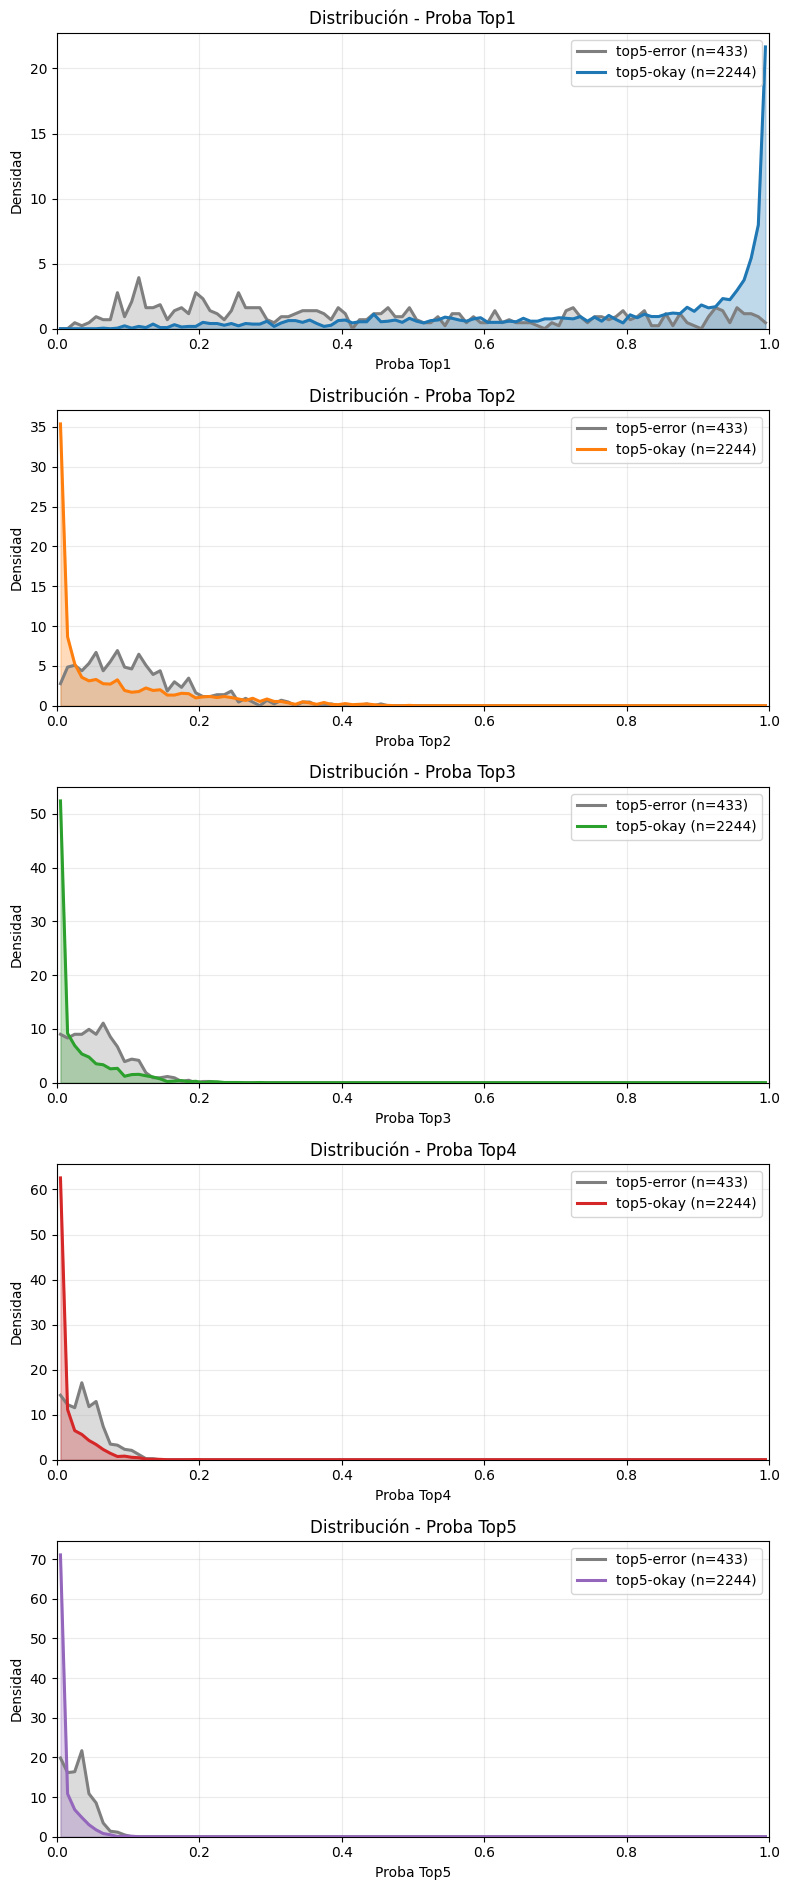

In [18]:
cols = [
    "Proba Top1",
    "Proba Top2",
    "Proba Top3",
    "Proba Top4",
    "Proba Top5",
]

plot_numeric_distributions_filter_vs_complement(
    df=test,
    mask=error,
    columns=cols,
    bins=100,
    density=True,
    label_filter="top5-error",
    label_complement="top5-okay",
    title_prefix="Distribución",
)

## Train sample

In [19]:
colspecs = [(0, 6), (6, None)]
data_type = {'HS06': str}
raw = pd.read_fwf('data/raw_data_HScodes_desc.txt',
                 colspecs=colspecs, header=None,
                 names=['HS06', 'GOODS_DESCRIPTION'],
                 dtype=data_type)

raw['True Label'] = raw['HS04'] = raw['HS06'].str[:4]
raw['True Chapter'] = raw['HS02'] = raw['HS06'].str[:2]

print("Nulls per column:")
print(raw.isnull().sum(), "\n")

print("Duplicate rows:", raw.duplicated().sum(), "\n")

# Dropping duplicates
raw.drop_duplicates(inplace=True)

raw

Nulls per column:
HS06                 0
GOODS_DESCRIPTION    0
True Label           0
HS04                 0
True Chapter         0
HS02                 0
dtype: int64 

Duplicate rows: 232220 



,HS06,GOODS_DESCRIPTION,True Label,HS04,True Chapter,HS02
0,271019,BRAKE FLUID DOT 4 50X200ML,2710,2710,27,27
1,847710,PLASTIC INJECTION MOULD MODEL 21A 110G DSM1010...,8477,8477,84,84
2,844399,LCD ASSEMBLY,8443,8443,84,84
3,848280,BEARING 22238 KCAW33C3 BRAND MCB,8482,8482,84,84
4,630900,USED HANDBAGS AND WALLETS,6309,6309,63,63
...,...,...,...,...,...,...
499959,854239,PCB OPTIONAL ADD. KROPT V4.0 (NEW OUT PUT CARD),8542,8542,85,85
499961,842091,CYLINDER (SDA80*10F003000001A),8420,8420,84,84
499970,830249,BEOTIC DEVICE,8302,8302,83,83
499981,901180,COMPOUND BINOCULAR MICROSCOPE,9011,9011,90,90


In [20]:
len(raw['True Label'].unique())

1133

In [21]:
train = raw.loc[~raw.index.isin(test.index)]

## Error analysis

### By HS code (HS02 chapters and HS04 headings)

This notebook performs an aggregated error analysis of the DistilBERT classifier by HS code. The goal is to understand whether model performance is related to class frequency, textual complexity, tokenization behavior, and predictive confidence.

### Steps

> **1. Training set characterization**

For each HS code, compute structural statistics such as:

- number of training samples,
- description length in words and characters,
- subtokenization indicator.

Output tables:
- `HS02_training_stats`
- `HS04_training_stats`

> **2. Test set characterization**

For each HS code, compute descriptive and prediction-related statistics based on the test set:

- number of test samples,
- description length in words and characters,
- subtokenization indicator,
- top-k correctness indicators,
- prediction score,
- top-k probability, margin, concentration, and entropy features.

Output tables:
- `HS02_test_stats`
- `HS04_test_stats`

> **3. Merge training and testing summaries**

Merge the training and test aggregated tables by HS code in order to analyze the relationship between:

- class representation in training,
- textual/tokenization complexity,
- predictive confidence,
- and class-level performance.

Main merged table:
- `HS04_merged`

> **4. Explanatory modeling**

Using the merged HS-level dataset:

- define structural and diagnostic feature sets,
- remove highly correlated features using mutual information,
- fit XGBoost models with repeated cross-validation,
- interpret the main drivers of class-level difficulty using SHAP.

#### Utils

In [22]:
def hs_frequencies_process(df, hs_codification = []):
    for hs_codi in hs_codification:

        df = df.merge(df[hs_codi].value_counts(), left_on=hs_codi, right_index=True)
        df.rename(columns={'count':f'{hs_codi}_samples'}, inplace=True)

    return df.sort_index()

def description_length(df, description_cols = []):
    for col in description_cols:

        df[f'{col}_len_words'] = df[col].apply(lambda x: len(x.split()))
        df[f'{col}_len_chars'] = df[col].apply(lambda x: len(x))

    return df.sort_index()

# Function to count OOV tokens in a description
def count_oov_tokens(description):
    tokens = tokenizer.tokenize(description)
    oov_tokens = [token for token in tokens if token not in vocab]
    return len(oov_tokens)

def count_unk_tokens(description):
    # Tokenize the description with truncation and padding
    tokens = tokenizer.tokenize(description)
    unk_token = "[UNK]"
    unk_count = tokens.count(unk_token)
    return unk_count

from transformers import DistilBertTokenizerFast
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

vocab = tokenizer.get_vocab()

def subtokenization_indicator(description):
    words = description.lower().split()
    tokens = tokenizer.tokenize(description)
    return len(tokens)/len(words)


def results_processing(df, top_k=5, eps=1e-12):
    """
    Enrich a top-k prediction results dataframe with evaluation and confidence features.

    Expected columns:
        - 'True Label'
        - 'Top1', ..., f'Top{top_k}'
        - 'Proba Top1', ..., f'Proba Top{top_k}'

    Adds:
        - true_top1 ... true_topK (cumulative)
        - pred_score
        - confidence / margin features
        - concentration features
        - entropy features
        - rank-weighted confidence
    """
    df = df.copy()

    top_cols = [f"Top{i}" for i in range(1, top_k + 1)]
    proba_cols = [f"Proba Top{i}" for i in range(1, top_k + 1)]

    # -----------------------------
    # true_topk cumulative flags
    # -----------------------------
    df["true_top1"] = df["True Label"] == df["Top1"]

    for i in range(2, top_k + 1):
        current_top_cols = [f"Top{j}" for j in range(1, i + 1)]
        df[f"true_top{i}"] = df.apply(
            lambda row: row["True Label"] in row[current_top_cols].values,
            axis=1
        )

    # -----------------------------
    # pred_score
    # Top1=top_k, Top2=top_k-1, ..., TopK=1, else 0
    # -----------------------------
    df["pred_score"] = 0
    for i in range(1, top_k + 1):
        score_value = top_k - i + 1
        df.loc[df["True Label"] == df[f"Top{i}"], "pred_score"] = score_value

    # -----------------------------
    # Basic probability matrix
    # -----------------------------
    probas = df[proba_cols].astype(float)

    # -----------------------------
    # Confidence / margin features
    # -----------------------------
    df["top1_proba"] = df["Proba Top1"]
    df["top1_top2_proba_diff"] = df["Proba Top1"] - df["Proba Top2"]
    df["top1_top2_proba_ratio"] = df["Proba Top1"] / (df["Proba Top2"] + eps)

    if top_k >= 3:
        df["top2_top3_proba_diff"] = df["Proba Top2"] - df["Proba Top3"]
        df["top2_top3_proba_ratio"] = df["Proba Top2"] / (df["Proba Top3"] + eps)

    if top_k >= 4:
        df["top3_top4_proba_diff"] = df["Proba Top3"] - df["Proba Top4"]
        df["top3_top4_proba_ratio"] = df["Proba Top3"] / (df["Proba Top4"] + eps)

    if top_k >= 5:
        df["top4_top5_proba_diff"] = df["Proba Top4"] - df["Proba Top5"]
        df["top4_top5_proba_ratio"] = df["Proba Top4"] / (df["Proba Top5"] + eps)

    # -----------------------------
    # Concentration features
    # -----------------------------
    df[f"sum_top{top_k}_proba"] = probas.sum(axis=1)
    df[f"mean_top{top_k}_proba"] = probas.mean(axis=1)
    df[f"std_top{top_k}_proba"] = probas.std(axis=1)
    df[f"max_top{top_k}_proba"] = probas.max(axis=1)
    df[f"min_top{top_k}_proba"] = probas.min(axis=1)
    df[f"range_top{top_k}_proba"] = df[f"max_top{top_k}_proba"] - df[f"min_top{top_k}_proba"]
    df[f"median_top{top_k}_proba"] = probas.median(axis=1)

    # -----------------------------
    # Entropy features
    # Note: entropy is computed after renormalizing only the top-k probs
    # -----------------------------
    probas_np = probas.to_numpy(dtype=float)
    probas_np = np.clip(probas_np, eps, None)

    probas_topk_norm = probas_np / probas_np.sum(axis=1, keepdims=True)
    entropy = -(probas_topk_norm * np.log(probas_topk_norm)).sum(axis=1)

    df[f"entropy_top{top_k}_proba"] = entropy
    df[f"normalized_entropy_top{top_k}"] = entropy / np.log(top_k)

    # -----------------------------
    # Rank-weighted confidence
    # Larger weight for earlier ranks
    # Example for top_k=5: [5,4,3,2,1]
    # -----------------------------
    weights = np.arange(top_k, 0, -1, dtype=float)
    df[f"weighted_top{top_k}_proba"] = probas.mul(weights, axis=1).sum(axis=1)

    # Optional normalized version
    df[f"normalized_weighted_top{top_k}_proba"] = (
        df[f"weighted_top{top_k}_proba"] / weights.sum()
    )

    return df


def flatten_columns(df, sep="_"):
    df = df.copy()

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [
            sep.join([str(x) for x in col if x is not None and str(x) != ""])
            for col in df.columns.to_flat_index()
        ]
    else:
        df.columns = [str(col) for col in df.columns]

    return df

In [23]:
test['True Chapter'] = test['True Label'].str[:2]
test['True Chapter'] = test['True Label'].str[:2]

### Train dataset

In [24]:
text_col = 'GOODS_DESCRIPTION'
labels = ['True Label','True Chapter']

# HS frequencies
train_df = hs_frequencies_process(train, hs_codification = labels)

# Description lenghts
train_df = description_length(train_df, description_cols=[text_col])

# Out-of-vocabulary (OOV) tokens 
# This seems unnecessary because of the robustness of the tokenizer, which subtokenization is breaking the words into known tokens
# Apply the function to each description and create a new column
# train_df['desc_oov_token_count'] = train_df[text_col].apply(count_oov_tokens)

# Apply the function to each description and create a new column
# train_df['UNK_token_count'] = train_df[text_col].apply(count_unk_tokens)

# Subtokenization indicator
train_df['subtokenization_indicator'] = train_df[text_col].apply(subtokenization_indicator)

display(train_df.head(2))
train_df.describe()

,HS06,GOODS_DESCRIPTION,True Label,HS04,True Chapter,HS02,True Label_samples,True Chapter_samples,GOODS_DESCRIPTION_len_words,GOODS_DESCRIPTION_len_chars,subtokenization_indicator
0,271019,BRAKE FLUID DOT 4 50X200ML,2710,2710,27,27,1165,1421,5,26,1.600000
1,847710,PLASTIC INJECTION MOULD MODEL 21A 110G DSM1010...,8477,8477,84,84,804,54337,7,53,2.428571


,True Label_samples,True Chapter_samples,GOODS_DESCRIPTION_len_words,GOODS_DESCRIPTION_len_chars,subtokenization_indicator
count,265103.000000,265103.000000,265103.000000,265103.000000,265103.000000
mean,1935.685801,21772.691886,4.588371,29.221718,1.947149
std,2095.300595,19740.345633,2.887478,18.472316,1.207769
min,1.000000,5.000000,1.000000,2.000000,1.000000
25%,403.000000,3453.000000,3.000000,17.000000,1.250000
50%,1120.000000,12092.000000,4.000000,25.000000,1.666667
75%,2798.000000,33236.000000,6.000000,36.000000,2.285714
max,8436.000000,54337.000000,41.000000,150.000000,59.000000


Grouping by HS codes

In [25]:
train_df.select_dtypes(include='number').columns.to_list()
agg_columns = labels

agg_dict = {col: ['count'] for col in agg_columns}

agg_columns = train_df.select_dtypes(include='number').columns.to_list()

agg_dict.update({col: ['sum','min', 'mean', 'median', 'max', 'std'] for col in agg_columns})

print(agg_dict)

# HS04
HS04_training_stats = train_df.groupby(labels[0]).agg(agg_dict).reset_index()
print(f"Stats for {labels[0]}")
display(HS04_training_stats)

# HS02
HS02_training_stats = train_df.groupby(labels[1]).agg(agg_dict).reset_index()
print(f"Stats for {labels[1]}")
display(HS02_training_stats)

{'True Label': ['count'], 'True Chapter': ['count'], 'True Label_samples': ['sum', 'min', 'mean', 'median', 'max', 'std'], 'True Chapter_samples': ['sum', 'min', 'mean', 'median', 'max', 'std'], 'GOODS_DESCRIPTION_len_words': ['sum', 'min', 'mean', 'median', 'max', 'std'], 'GOODS_DESCRIPTION_len_chars': ['sum', 'min', 'mean', 'median', 'max', 'std'], 'subtokenization_indicator': ['sum', 'min', 'mean', 'median', 'max', 'std']}
Stats for True Label


True Label       True Chapter True Label_samples                       \
                count        count                sum min  mean median max   
0          0101     7            7                 49   7   7.0    7.0   7   
1          0102    10           10                100  10  10.0   10.0  10   
2          0103     1            1                  1   1   1.0    1.0   1   
3          0104     3            3                  9   3   3.0    3.0   3   
4          0105    76           76               5776  76  76.0   76.0  76   
...         ...   ...          ...                ...  ..   ...    ...  ..   
1124       9701    51           51               2601  51  51.0   51.0  51   
1125       9702     1            1                  1   1   1.0    1.0   1   
1126       9703    30           30                900  30  30.0   30.0  30   
1127       9704     6            6                 36   6   6.0    6.0   6   
1128       9705     4            4                 16   4   4.0    4.0   4   

          True Chapter_samples  ... GOODS_DESCRIPTION_len_chars              \
      std                  sum  ...                        mean median  max   
0     0.0                  896  ...                   29.000000   31.0   46   
1     0.0                 1280  ...                   17.900000   15.5   34   
2     NaN                  128  ...                    4.000000    4.0    4   
3     0.0                  384  ...                   11.000000    9.0   20   
4     0.0                 9728  ...                   44.565789   37.0  124   
...   ...                  ...  ...                         ...    ...  ...   
1124  0.0                 4692  ...                   21.098039   17.0   71   
1125  NaN                   92  ...                   14.000000   14.0   14   
1126  0.0                 2760  ...                   21.833333   17.0   74   
1127  0.0                  552  ...                   16.666667   14.0   30   
1128  0.0                  368  ...                   18.750000   15.0   37   

                subtokenization_indicator                                     \
            std                       sum  min      mean    median       max   
0     11.401754                  9.238095  1.0  1.319728  1.285714  1.666667   
1      9.757618                 13.333333  1.0  1.333333  1.000000  2.333333   
2           NaN                  1.000000  1.0  1.000000  1.000000  1.000000   
3      8.185353                  3.500000  1.0  1.166667  1.000000  1.500000   
4     23.405034                107.874584  1.0  1.419402  1.285714  2.687500   
...         ...                       ...  ...       ...       ...       ...   
1124  14.601719                 69.859829  1.0  1.369801  1.000000  4.000000   
1125        NaN                  1.000000  1.0  1.000000  1.000000  1.000000   
1126  14.462993                 50.133333  1.0  1.671111  1.416667  4.000000   
1127   9.025889                  7.000000  1.0  1.166667  1.000000  1.750000   
1128  12.632630                  6.666667  1.0  1.666667  1.500000  2.666667   

                
           std  
0     0.255646  
1     0.496904  
2          NaN  
3     0.288675  
4     0.411470  
...        ...  
1124  0.649436  
1125       NaN  
1126  0.791162  
1127  0.302765  
1128  0.816497  

[1129 rows x 33 columns]

Stats for True Chapter


True Chapter True Label True Chapter True Label_samples                    \
                     count        count                sum  min         mean   
0            01        128          128               6896    1    53.875000   
1            02        289          289              44297    1   153.276817   
2            03         61           61                775    1    12.704918   
3            04       1219         1219             410587    1   336.822806   
4            05         15           15                 45    1     3.000000   
..          ...        ...          ...                ...  ...          ...   
91           93         64           64                832    3    13.000000   
92           94       7851         7851           18339303  220  2335.919373   
93           95       4148         4148            6236544   26  1503.506268   
94           96       3054         3054            1329096    2   435.198428   
95           97         92           92               3554    1    38.630435   

                              True Chapter_samples  ...  \
    median   max          std                  sum  ...   
0     76.0    76    27.865820                16384  ...   
1    206.0   206    83.516213                83521  ...   
2     14.0    20     6.017597                 3721  ...   
3    411.0   445   144.169178              1485961  ...   
4      3.0     5     1.603567                  225  ...   
..     ...   ...          ...                  ...  ...   
91    15.0    20     6.071008                 4096  ...   
92  2602.0  3200  1041.664798             61638201  ...   
93  1464.0  1967   591.619971             17205904  ...   
94   265.0   875   322.488900              9326916  ...   
95    51.0    51    15.772920                 8464  ...   

   GOODS_DESCRIPTION_len_chars                         \
                          mean median  max        std   
0                    34.382812   30.0  124  23.000897   
1                    33.695502   32.0   89  15.728955   
2                    18.196721   15.0   54  10.934380   
3                    35.368335   30.0   95  19.162935   
4                    13.666667   14.0   30   5.802298   
..                         ...    ...  ...        ...   
91                   24.656250   20.0   68  16.408688   
92                   25.794931   21.0  150  17.274641   
93                   23.895130   21.0  150  12.996219   
94                   24.354944   21.0  132  15.018748   
95                   20.869565   17.0   74  13.991534   

   subtokenization_indicator                                           
                         sum  min      mean    median   max       std  
0                 179.771013  1.0  1.404461  1.285714   3.0  0.450030  
1                 840.670169  1.0  2.908893  1.666667  33.0  4.786007  
2                  94.851587  1.0  1.554944  1.333333   3.4  0.613188  
3                3509.360088  1.0  2.878884  1.750000  36.0  4.581980  
4                  20.883333  1.0  1.392222  1.333333   2.0  0.401429  
..                       ...  ...       ...       ...   ...       ...  
91                130.598810  1.0  2.040606  1.750000   6.5  1.173693  
92              12363.957961  1.0  1.574826  1.333333  16.0  0.861405  
93               6048.684260  1.0  1.458217  1.333333  10.5  0.632885  
94               5069.099647  1.0  1.659823  1.500000  10.5  0.817083  
95                134.659829  1.0  1.463694  1.000000   4.0  0.698100  

[96 rows x 33 columns]

### Test dataset

In [26]:
text_col = 'Description'
labels = ['True Label','True Chapter']

# HS frequencies
test_df = hs_frequencies_process(test, hs_codification = labels)

# Description lenghts
test_df = description_length(test_df, description_cols=[text_col])

# Out-of-vocabulary (OOV) tokens 
# This seems unnecessary because of the robustness of the tokenizer, which subtokenization is breaking the words into known tokens
# Apply the function to each description and create a new column
# test_df['desc_oov_token_count'] = test_df[text_col].apply(count_oov_tokens)

# Apply the function to each description and create a new column
# test_df['UNK_token_count'] = test_df[text_col].apply(count_unk_tokens)

# Subtokenization indicator
test_df['subtokenization_indicator'] = test_df[text_col].apply(subtokenization_indicator)

# Result processing
test_df = results_processing(test_df)

display(test_df.head(2))
test_df.describe()

,Description,True Label,Top1,Proba Top1,Top2,Proba Top2,Top3,Proba Top3,Top4,Proba Top4,...,mean_top5_proba,std_top5_proba,max_top5_proba,min_top5_proba,range_top5_proba,median_top5_proba,entropy_top5_proba,normalized_entropy_top5,weighted_top5_proba,normalized_weighted_top5_proba
131,D. LIGHT SOLAR PANEL,8541,8541,0.724253,9405,0.175927,8528,0.010541,8504,0.009514,...,0.185764,0.309526,0.724253,0.008586,0.715667,0.010541,0.650182,0.403981,4.384210,0.292281
146,"THERMAL PRINTER,SEIKO-PART NO.LTP01-245-11",8473,8443,0.989610,8422,0.003666,8442,0.000639,8477,0.000617,...,0.198969,0.441984,0.989610,0.000314,0.989296,0.000639,0.037749,0.023455,4.966183,0.331079


,Proba Top1,Proba Top2,Proba Top3,Proba Top4,Proba Top5,True Label_samples,True Chapter_samples,Description_len_words,Description_len_chars,subtokenization_indicator,...,mean_top5_proba,std_top5_proba,max_top5_proba,min_top5_proba,range_top5_proba,median_top5_proba,entropy_top5_proba,normalized_entropy_top5,weighted_top5_proba,normalized_weighted_top5_proba
count,2677.000000,2677.000000,2677.000000,2677.000000,2677.000000,2677.000000,2677.000000,2677.000000,2677.000000,2677.000000,...,2677.000000,2677.000000,2677.000000,2677.000000,2677.000000,2677.000000,2677.000000,2677.000000,2677.000000,2677.000000
mean,0.734021,0.084357,0.033819,0.019768,0.013127,20.820695,223.439298,4.601046,29.391109,1.956006,...,0.177018,0.318030,0.734021,0.013127,0.720894,0.033819,0.564424,0.350696,4.161653,0.277444
std,0.281109,0.096897,0.042700,0.025935,0.017717,22.846844,205.754506,2.854462,18.295199,1.222236,...,0.034178,0.133916,0.281109,0.017717,0.296211,0.042700,0.517858,0.321763,1.047521,0.069835
min,0.024027,0.000007,0.000006,0.000003,0.000002,1.000000,1.000000,1.000000,3.000000,1.000000,...,0.020433,0.002047,0.024027,0.000002,0.004985,0.000006,0.000279,0.000174,0.317229,0.021149
25%,0.518378,0.005767,0.001884,0.000996,0.000649,4.000000,40.000000,3.000000,17.000000,1.272727,...,0.170109,0.215717,0.518378,0.000649,0.496312,0.001884,0.071172,0.044222,3.701638,0.246776
50%,0.856810,0.048121,0.014689,0.007398,0.004559,12.000000,126.000000,4.000000,25.000000,1.666667,...,0.193378,0.372965,0.856810,0.004559,0.850222,0.014689,0.409467,0.254416,4.641285,0.309419
75%,0.980096,0.134238,0.054071,0.031976,0.020371,26.000000,335.000000,6.000000,36.000000,2.300000,...,0.198850,0.437060,0.980096,0.020371,0.979221,0.054071,1.014566,0.630385,4.945205,0.329680
max,0.999904,0.491022,0.289831,0.197753,0.109674,88.000000,564.000000,28.000000,150.000000,24.000000,...,0.199999,0.447168,0.999904,0.109674,0.999900,0.289831,1.605572,0.997598,4.999843,0.333323


Grouping by HS codes

In [27]:
test_df.select_dtypes(include='number').columns.to_list()
agg_columns = labels

agg_dict = {col: ['count'] for col in agg_columns}

agg_columns = test_df.select_dtypes(include='number').columns.to_list()

agg_dict.update({col: ['sum','min', 'mean', 'median', 'max', 'std'] for col in agg_columns})

print(agg_dict)

# HS04
HS04_test_stats = test_df.groupby(labels[0]).agg(agg_dict).reset_index()
print(f"Stats for {labels[0]}")
display(HS04_test_stats)

# HS02
HS02_test_stats = test_df.groupby(labels[1]).agg(agg_dict).reset_index()
print(f"Stats for {labels[1]}")
display(HS02_test_stats)

{'True Label': ['count'], 'True Chapter': ['count'], 'Proba Top1': ['sum', 'min', 'mean', 'median', 'max', 'std'], 'Proba Top2': ['sum', 'min', 'mean', 'median', 'max', 'std'], 'Proba Top3': ['sum', 'min', 'mean', 'median', 'max', 'std'], 'Proba Top4': ['sum', 'min', 'mean', 'median', 'max', 'std'], 'Proba Top5': ['sum', 'min', 'mean', 'median', 'max', 'std'], 'True Label_samples': ['sum', 'min', 'mean', 'median', 'max', 'std'], 'True Chapter_samples': ['sum', 'min', 'mean', 'median', 'max', 'std'], 'Description_len_words': ['sum', 'min', 'mean', 'median', 'max', 'std'], 'Description_len_chars': ['sum', 'min', 'mean', 'median', 'max', 'std'], 'subtokenization_indicator': ['sum', 'min', 'mean', 'median', 'max', 'std'], 'pred_score': ['sum', 'min', 'mean', 'median', 'max', 'std'], 'top1_proba': ['sum', 'min', 'mean', 'median', 'max', 'std'], 'top1_top2_proba_diff': ['sum', 'min', 'mean', 'median', 'max', 'std'], 'top1_top2_proba_ratio': ['sum', 'min', 'mean', 'median', 'max', 'std'], 'to

True Label       True Chapter Proba Top1                                \
               count        count        sum       min      mean    median   
0         0103     1            1   0.214668  0.214668  0.214668  0.214668   
1         0203     2            2   1.182966  0.199555  0.591483  0.591483   
2         0207     1            1   0.353084  0.353084  0.353084  0.353084   
3         0210     1            1   0.614027  0.614027  0.614027  0.614027   
4         0308     1            1   0.197738  0.197738  0.197738  0.197738   
..         ...   ...          ...        ...       ...       ...       ...   
502       9617     4            4   3.270781  0.487757  0.817695  0.897959   
503       9619     5            5   4.978730  0.993479  0.995746  0.995747   
504       9620     1            1   0.460498  0.460498  0.460498  0.460498   
505       9701     1            1   0.597989  0.597989  0.597989  0.597989   
506       9703     1            1   0.286866  0.286866  0.286866  0.286866   

                        Proba Top2  ... weighted_top5_proba            \
          max       std        sum  ...                mean    median   
0    0.214668       NaN   0.044709  ...            1.477522  1.477522   
1    0.983411  0.554270   0.165408  ...            3.527342  3.527342   
2    0.353084       NaN   0.064597  ...            2.229181  2.229181   
3    0.614027       NaN   0.161735  ...            3.843982  3.843982   
4    0.197738       NaN   0.146472  ...            2.117339  2.117339   
..        ...       ...        ...  ...                 ...       ...   
502  0.987104  0.225364   0.512752  ...            4.668933  4.684965   
503  0.997176  0.001534   0.012348  ...            4.990358  4.991759   
504  0.460498       NaN   0.078083  ...            2.851297  2.851297   
505  0.597989       NaN   0.180189  ...            4.022445  4.022445   
506  0.286866       NaN   0.233733  ...            2.784258  2.784258   

                        normalized_weighted_top5_proba                      \
          max       std                            sum       min      mean   
0    1.477522       NaN                       0.098501  0.098501  0.098501   
1    4.950674  2.012895                       0.470312  0.140267  0.235156   
2    2.229181       NaN                       0.148612  0.148612  0.148612   
3    3.843982       NaN                       0.256265  0.256265  0.256265   
4    2.117339       NaN                       0.141156  0.141156  0.141156   
..        ...       ...                            ...       ...       ...   
502  4.965839  0.284776                       1.245049  0.289331  0.311262   
503  4.992774  0.003770                       1.663453  0.332246  0.332691   
504  2.851297       NaN                       0.190086  0.190086  0.190086   
505  4.022445       NaN                       0.268163  0.268163  0.268163   
506  2.784258       NaN                       0.185617  0.185617  0.185617   

                                   
       median       max       std  
0    0.098501  0.098501       NaN  
1    0.235156  0.330045  0.134193  
2    0.148612  0.148612       NaN  
3    0.256265  0.256265       NaN  
4    0.141156  0.141156       NaN  
..        ...       ...       ...  
502  0.312331  0.331056  0.018985  
503  0.332784  0.332852  0.000251  
504  0.190086  0.190086       NaN  
505  0.268163  0.268163       NaN  
506  0.185617  0.185617       NaN  

[507 rows x 189 columns]

Stats for True Chapter


True Chapter True Label True Chapter Proba Top1                      \
                     count        count        sum       min      mean   
0            01          1            1   0.214668  0.214668  0.214668   
1            02          4            4   2.150077  0.199555  0.537519   
2            03          1            1   0.197738  0.197738  0.197738   
3            04         14           14  11.560909  0.200810  0.825779   
4            06          1            1   0.978046  0.978046  0.978046   
..          ...        ...          ...        ...       ...       ...   
74           92          1            1   0.712842  0.712842  0.712842   
75           94         70           70  55.669527  0.107165  0.795279   
76           95         43           43  35.091726  0.184388  0.816087   
77           96         37           37  28.308758  0.178545  0.765102   
78           97          2            2   0.884854  0.286866  0.442427   

                                 Proba Top2  ... weighted_top5_proba  \
      median       max       std        sum  ...                mean   
0   0.214668  0.214668       NaN   0.044709  ...            1.477522   
1   0.483555  0.983411  0.342982   0.391740  ...            3.281962   
2   0.197738  0.197738       NaN   0.146472  ...            2.117339   
3   0.986908  0.999799  0.283921   0.588928  ...            4.391633   
4   0.978046  0.978046       NaN   0.014527  ...            4.957780   
..       ...       ...       ...        ...  ...                 ...   
74  0.712842  0.712842       NaN   0.086399  ...            4.058627   
75  0.908913  0.996466  0.235783   7.259865  ...            4.487655   
76  0.958247  0.999817  0.239879   2.464543  ...            4.411699   
77  0.878661  0.999177  0.276296   2.694573  ...            4.211383   
78  0.442427  0.597989  0.219997   0.413922  ...            3.403351   

                                 normalized_weighted_top5_proba            \
      median       max       std                            sum       min   
0   1.477522  1.477522       NaN                       0.098501  0.098501   
1   3.036581  4.950674  1.365819                       0.875190  0.140267   
2   2.117339  2.117339       NaN                       0.141156  0.141156   
3   4.953344  4.999225  1.106393                       4.098858  0.089084   
4   4.957780  4.957780       NaN                       0.330519  0.330519   
..       ...       ...       ...                            ...       ...   
74  4.058627  4.058627       NaN                       0.270575  0.270575   
75  4.798845  4.992736  0.788299                      20.942388  0.076301   
76  4.879353  4.999235  0.865070                      12.646871  0.096947   
77  4.763579  4.997134  1.086591                      10.388078  0.087732   
78  3.403351  4.022445  0.875530                       0.453780  0.185617   

                                            
        mean    median       max       std  
0   0.098501  0.098501  0.098501       NaN  
1   0.218797  0.202439  0.330045  0.091055  
2   0.141156  0.141156  0.141156       NaN  
3   0.292776  0.330223  0.333282  0.073760  
4   0.330519  0.330519  0.330519       NaN  
..       ...       ...       ...       ...  
74  0.270575  0.270575  0.270575       NaN  
75  0.299177  0.319923  0.332849  0.052553  
76  0.294113  0.325290  0.333282  0.057671  
77  0.280759  0.317572  0.333142  0.072439  
78  0.226890  0.226890  0.268163  0.058369  

[79 rows x 189 columns]

### Merge testing set and results with training set analysis

HS04_training_stats

In [28]:
HS04_training_stats

True Label       True Chapter True Label_samples                       \
                count        count                sum min  mean median max   
0          0101     7            7                 49   7   7.0    7.0   7   
1          0102    10           10                100  10  10.0   10.0  10   
2          0103     1            1                  1   1   1.0    1.0   1   
3          0104     3            3                  9   3   3.0    3.0   3   
4          0105    76           76               5776  76  76.0   76.0  76   
...         ...   ...          ...                ...  ..   ...    ...  ..   
1124       9701    51           51               2601  51  51.0   51.0  51   
1125       9702     1            1                  1   1   1.0    1.0   1   
1126       9703    30           30                900  30  30.0   30.0  30   
1127       9704     6            6                 36   6   6.0    6.0   6   
1128       9705     4            4                 16   4   4.0    4.0   4   

          True Chapter_samples  ... GOODS_DESCRIPTION_len_chars              \
      std                  sum  ...                        mean median  max   
0     0.0                  896  ...                   29.000000   31.0   46   
1     0.0                 1280  ...                   17.900000   15.5   34   
2     NaN                  128  ...                    4.000000    4.0    4   
3     0.0                  384  ...                   11.000000    9.0   20   
4     0.0                 9728  ...                   44.565789   37.0  124   
...   ...                  ...  ...                         ...    ...  ...   
1124  0.0                 4692  ...                   21.098039   17.0   71   
1125  NaN                   92  ...                   14.000000   14.0   14   
1126  0.0                 2760  ...                   21.833333   17.0   74   
1127  0.0                  552  ...                   16.666667   14.0   30   
1128  0.0                  368  ...                   18.750000   15.0   37   

                subtokenization_indicator                                     \
            std                       sum  min      mean    median       max   
0     11.401754                  9.238095  1.0  1.319728  1.285714  1.666667   
1      9.757618                 13.333333  1.0  1.333333  1.000000  2.333333   
2           NaN                  1.000000  1.0  1.000000  1.000000  1.000000   
3      8.185353                  3.500000  1.0  1.166667  1.000000  1.500000   
4     23.405034                107.874584  1.0  1.419402  1.285714  2.687500   
...         ...                       ...  ...       ...       ...       ...   
1124  14.601719                 69.859829  1.0  1.369801  1.000000  4.000000   
1125        NaN                  1.000000  1.0  1.000000  1.000000  1.000000   
1126  14.462993                 50.133333  1.0  1.671111  1.416667  4.000000   
1127   9.025889                  7.000000  1.0  1.166667  1.000000  1.750000   
1128  12.632630                  6.666667  1.0  1.666667  1.500000  2.666667   

                
           std  
0     0.255646  
1     0.496904  
2          NaN  
3     0.288675  
4     0.411470  
...        ...  
1124  0.649436  
1125       NaN  
1126  0.791162  
1127  0.302765  
1128  0.816497  

[1129 rows x 33 columns]

In [29]:
HS04_training_stats_flat = flatten_columns(HS04_training_stats)
HS04_test_stats_flat = flatten_columns(HS04_test_stats)

HS04_merged = HS04_training_stats_flat.merge(HS04_test_stats_flat, how='left', on='True Label', suffixes=('_trainset', '_testset'))

In [30]:
HS04_merged

,True Label,True Label_count_trainset,True Chapter_count_trainset,True Label_samples_sum_trainset,True Label_samples_min_trainset,True Label_samples_mean_trainset,True Label_samples_median_trainset,True Label_samples_max_trainset,True Label_samples_std_trainset,True Chapter_samples_sum_trainset,...,weighted_top5_proba_mean,weighted_top5_proba_median,weighted_top5_proba_max,weighted_top5_proba_std,normalized_weighted_top5_proba_sum,normalized_weighted_top5_proba_min,normalized_weighted_top5_proba_mean,normalized_weighted_top5_proba_median,normalized_weighted_top5_proba_max,normalized_weighted_top5_proba_std
0,0101,7,7,49,7,7.0,7.0,7,0.0,896,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0102,10,10,100,10,10.0,10.0,10,0.0,1280,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0103,1,1,1,1,1.0,1.0,1,NaN,128,...,1.477522,1.477522,1.477522,NaN,0.098501,0.098501,0.098501,0.098501,0.098501,NaN
3,0104,3,3,9,3,3.0,3.0,3,0.0,384,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0105,76,76,5776,76,76.0,76.0,76,0.0,9728,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1124,9701,51,51,2601,51,51.0,51.0,51,0.0,4692,...,4.022445,4.022445,4.022445,NaN,0.268163,0.268163,0.268163,0.268163,0.268163,NaN
1125,9702,1,1,1,1,1.0,1.0,1,NaN,92,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1126,9703,30,30,900,30,30.0,30.0,30,0.0,2760,...,2.784258,2.784258,2.784258,NaN,0.185617,0.185617,0.185617,0.185617,0.185617,NaN
1127,9704,6,6,36,6,6.0,6.0,6,0.0,552,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Flatten column names

In [31]:
numeric_and_bool = HS04_merged.select_dtypes(['number','bool']).columns.tolist()

numeric_and_bool

['True Label_count_trainset',
 'True Chapter_count_trainset',
 'True Label_samples_sum_trainset',
 'True Label_samples_min_trainset',
 'True Label_samples_mean_trainset',
 'True Label_samples_median_trainset',
 'True Label_samples_max_trainset',
 'True Label_samples_std_trainset',
 'True Chapter_samples_sum_trainset',
 'True Chapter_samples_min_trainset',
 'True Chapter_samples_mean_trainset',
 'True Chapter_samples_median_trainset',
 'True Chapter_samples_max_trainset',
 'True Chapter_samples_std_trainset',
 'GOODS_DESCRIPTION_len_words_sum',
 'GOODS_DESCRIPTION_len_words_min',
 'GOODS_DESCRIPTION_len_words_mean',
 'GOODS_DESCRIPTION_len_words_median',
 'GOODS_DESCRIPTION_len_words_max',
 'GOODS_DESCRIPTION_len_words_std',
 'GOODS_DESCRIPTION_len_chars_sum',
 'GOODS_DESCRIPTION_len_chars_min',
 'GOODS_DESCRIPTION_len_chars_mean',
 'GOODS_DESCRIPTION_len_chars_median',
 'GOODS_DESCRIPTION_len_chars_max',
 'GOODS_DESCRIPTION_len_chars_std',
 'subtokenization_indicator_sum_trainset',
 's

#### Cases quick review

In [77]:
cols = ['True Label','True Label_count_trainset',
'GOODS_DESCRIPTION_len_chars_mean',
'subtokenization_indicator_mean_trainset',
'True Label_count_testset',
'Description_len_chars_mean',
'subtokenization_indicator_mean_testset',
'top1_proba_mean',
'pred_score_mean']

condition = HS04_merged['True Label_count_testset'] > 5

HS04_merged[cols].loc[condition].sort_values(by='pred_score_mean', ascending=False).head(10)

,True Label,True Label_count_trainset,GOODS_DESCRIPTION_len_chars_mean,subtokenization_indicator_mean_trainset,True Label_count_testset,Description_len_chars_mean,subtokenization_indicator_mean_testset,top1_proba_mean,pred_score_mean
116,1511,247,25.566802,1.574851,7.0,25.000000,1.547619,0.987643,5.000000
341,3303,464,27.497845,1.739121,7.0,27.857143,1.927778,0.914126,5.000000
316,3004,1425,36.105965,2.537188,11.0,28.181818,2.765152,0.867505,5.000000
394,3901,564,32.856383,2.459181,9.0,29.222222,2.371296,0.925186,5.000000
891,8429,582,38.070447,2.253668,8.0,56.125000,2.267743,0.967829,5.000000
1112,9609,265,28.218868,1.784355,6.0,25.666667,2.069444,0.730606,5.000000
1014,8711,2916,58.425583,3.194436,19.0,61.263158,3.381328,0.986985,4.947368
133,1704,1561,30.530429,2.098985,16.0,35.500000,3.276240,0.914996,4.937500
430,4011,1847,34.593936,2.437331,25.0,34.560000,2.683146,0.966375,4.920000
1004,8701,1386,43.712121,1.973571,11.0,61.636364,1.975363,0.998585,4.909091


In [83]:
HS04_merged[cols].loc[condition].sort_values(by='pred_score_mean', ascending=False).head(10).to_clipboard(index=False, excel=True)

In [81]:
HS04_merged[cols].loc[condition].sort_values(by='pred_score_mean', ascending=False).tail(10)

,True Label,True Label_count_trainset,GOODS_DESCRIPTION_len_chars_mean,subtokenization_indicator_mean_trainset,True Label_count_testset,Description_len_chars_mean,subtokenization_indicator_mean_testset,top1_proba_mean,pred_score_mean
419,3926,1288,25.614130,1.764216,7.0,29.285714,2.147619,0.598332,2.571429
761,7306,297,31.915825,2.013605,7.0,32.000000,1.507256,0.469527,2.571429
413,3920,684,29.676901,1.805590,9.0,23.111111,1.530556,0.524694,2.555556
877,8415,450,30.300000,1.978599,6.0,24.500000,1.925926,0.577787,2.333333
881,8419,701,31.179743,1.751467,7.0,24.857143,2.152381,0.583700,1.714286
1022,8803,255,25.439216,1.925050,7.0,33.000000,2.179592,0.598434,1.428571
935,8473,676,29.676036,2.031146,8.0,29.625000,2.453125,0.585848,1.375000
989,8543,619,31.003231,1.930285,13.0,36.923077,1.699717,0.486514,1.076923
941,8479,1119,33.418231,1.823411,11.0,26.272727,2.679942,0.495512,1.000000
819,7616,612,31.944444,1.714345,6.0,20.333333,1.233333,0.523819,0.833333


In [86]:
HS04_merged[cols].loc[condition].sort_values(by='pred_score_mean', ascending=False).tail(10).to_clipboard(index=False, excel=True)

### Correlations

In [47]:
HS04_merged_ = HS04_merged.loc[HS04_merged['True Label_count_testset']> 1]

Helpers for correlations

In [48]:
def _match_group(col: str, group_patterns: Dict[str, List[str]]) -> Optional[str]:
    """
    Devuelve el nombre del grupo al que pertenece la columna según regex/patrones.
    El primer match encontrado gana.
    """
    for group_name, patterns in group_patterns.items():
        for pat in patterns:
            if re.search(pat, col):
                return group_name
    return None


def _build_short_label(col: str, group_name: str) -> str:
    """
    Genera una etiqueta corta y legible para usar en el heatmap.
    """
    label = col

    replacements = {
        "GOODS_DESCRIPTION_": "",
        "Description_": "",
        "pred_score_": "",
        "_trainset": "",
        "_testset": "",
    }

    for old, new in replacements.items():
        label = label.replace(old, new)

    label = re.sub(r"_+", "_", label).strip("_")

    # Prefijo corto por grupo
    prefix_map = {
        "trainset": "tr_",
        "train_texts": "txttr_",
        "testset": "te_",
        "test_texts": "txtte_",
        "proba": "pr_",
        "target": "y_",
    }

    prefix = prefix_map.get(group_name, "")
    short = f"{prefix}{label}"

    # Evitar labels larguísimos
    if len(short) > 28:
        short = short[:25] + "..."

    return short


def select_and_order_corr_columns(
    df: pd.DataFrame,
    group_patterns: Optional[Dict[str, List[str]]] = None,
    extra_numeric_cols: Optional[List[str]] = None,
) -> Tuple[List[str], pd.DataFrame]:
    """
    Selecciona columnas numéricas relevantes para la matriz de correlación,
    las asigna a grupos y devuelve:
      - lista de columnas ordenadas
      - metadata dataframe con columna, grupo y short_label
    """
    if group_patterns is None:
        group_patterns = {
            "trainset": [r"_trainset$"],
            "train_texts": [r"^GOODS_DESCRIPTION_"],
            "testset": [r"_testset$"],
            "test_texts": [r"^Description_"],
            "proba": [r"_proba_"],
            "target": [r"^pred_score_"],
        }

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    rows = []
    for col in numeric_cols:
        group = _match_group(col, group_patterns)
        if group is not None:
            rows.append({
                "column": col,
                "group": group,
                "short_label": _build_short_label(col, group)
            })

    meta = pd.DataFrame(rows)

    if extra_numeric_cols:
        extra_numeric_cols = [c for c in extra_numeric_cols if c in numeric_cols]
        extra_rows = []
        for col in extra_numeric_cols:
            if col not in meta["column"].tolist():
                extra_rows.append({
                    "column": col,
                    "group": "other",
                    "short_label": col if len(col) <= 28 else col[:25] + "..."
                })
        if extra_rows:
            meta = pd.concat([meta, pd.DataFrame(extra_rows)], ignore_index=True)

    group_order = ["trainset", "train_texts", "testset", "test_texts", "proba", "target", "other"]
    meta["group"] = pd.Categorical(meta["group"], categories=group_order, ordered=True)
    meta = meta.sort_values(["group", "column"]).reset_index(drop=True)

    ordered_cols = meta["column"].tolist()
    return ordered_cols, meta


def plot_grouped_correlation_matrix(
    df: pd.DataFrame,
    method: str = "pearson",
    figsize: Optional[Tuple[int, int]] = None,
    min_abs_corr: Optional[float] = None,
    show_upper_triangle: bool = False,
    annotate: bool = False,
    cmap: str = "RdBu_r",
    title: str = "Correlation matrix grouped by variable families",
    group_patterns: Optional[Dict[str, List[str]]] = None,
    savepath: Optional[str] = None,
    dpi: int = 300,
):
    """
    Grafica una matriz de correlación agrupada y ordenada por familias de variables.
    Ideal para reportes cuando hay muchas columnas.
    """
    cols, meta = select_and_order_corr_columns(df, group_patterns=group_patterns)

    if len(cols) == 0:
        raise ValueError("No se encontraron columnas numéricas que coincidan con los patrones definidos.")

    corr = df[cols].corr(method=method)

    # Filtro opcional visual: dejar correlaciones chicas en blanco
    corr_plot = corr.copy()
    if min_abs_corr is not None:
        corr_plot = corr_plot.where(corr_plot.abs() >= min_abs_corr)

    # Renombrar ejes con labels cortos
    label_map = dict(zip(meta["column"], meta["short_label"]))
    corr_plot = corr_plot.rename(index=label_map, columns=label_map)

    n = len(cols)
    if figsize is None:
        # Escalado automático razonable
        base = max(10, min(28, int(n * 0.35)))
        figsize = (base, base)

    mask = None
    if not show_upper_triangle:
        mask = np.triu(np.ones_like(corr_plot, dtype=bool), k=1)

    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        corr_plot,
        mask=mask,
        cmap=cmap,
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        linewidths=0.15,
        linecolor="lightgray",
        cbar_kws={"shrink": 0.75, "label": f"{method.capitalize()} correlation"},
        annot=annotate,
        fmt=".2f",
        ax=ax,
    )

    ax.set_title(title, fontsize=14, pad=16)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)

    # Líneas separadoras entre grupos
    group_counts = meta.groupby("group", observed=True).size()
    group_counts = group_counts[group_counts > 0]

    boundaries = np.cumsum(group_counts.values)[:-1]
    for b in boundaries:
        ax.axhline(b, color="black", linewidth=1.0)
        ax.axvline(b, color="black", linewidth=1.0)

    # Etiquetas de grupos
    group_positions = []
    start = 0
    for g, count in group_counts.items():
        center = start + count / 2
        group_positions.append((g, center))
        start += count

    # Texto arriba
    for g, center in group_positions:
        ax.text(center, -1.8, g, ha="center", va="center", fontsize=9, fontweight="bold")
        ax.text(-1.8, center, g, ha="center", va="center", fontsize=9, fontweight="bold", rotation=90)

    plt.tight_layout()

    if savepath is not None:
        plt.savefig(savepath, dpi=dpi, bbox_inches="tight")

    plt.show()

    return corr, meta


def build_group_summary_matrix(
    df: pd.DataFrame,
    method: str = "pearson",
    summary_stat: str = "mean_abs",
    group_patterns: Optional[Dict[str, List[str]]] = None,
) -> pd.DataFrame:
    """
    Construye una matriz resumen entre grupos.
    Cada celda resume las correlaciones entre las variables de dos grupos.
    summary_stat:
      - 'mean_abs': media del valor absoluto
      - 'max_abs': máximo valor absoluto
      - 'mean': media con signo
    """
    cols, meta = select_and_order_corr_columns(df, group_patterns=group_patterns)
    if len(cols) == 0:
        raise ValueError("No se encontraron columnas numéricas que coincidan con los patrones definidos.")

    corr = df[cols].corr(method=method)

    groups = meta["group"].dropna().unique().tolist()
    summary = pd.DataFrame(index=groups, columns=groups, dtype=float)

    group_to_cols = meta.groupby("group", observed=True)["column"].apply(list).to_dict()

    for g1 in groups:
        for g2 in groups:
            sub = corr.loc[group_to_cols[g1], group_to_cols[g2]].values

            if g1 == g2:
                # Excluir diagonal en bloques internos
                if sub.shape[0] == sub.shape[1]:
                    mask = ~np.eye(sub.shape[0], dtype=bool)
                    vals = sub[mask]
                else:
                    vals = sub.ravel()
            else:
                vals = sub.ravel()

            vals = vals[~np.isnan(vals)]
            if len(vals) == 0:
                summary.loc[g1, g2] = np.nan
            elif summary_stat == "mean_abs":
                summary.loc[g1, g2] = np.mean(np.abs(vals))
            elif summary_stat == "max_abs":
                summary.loc[g1, g2] = np.max(np.abs(vals))
            elif summary_stat == "mean":
                summary.loc[g1, g2] = np.mean(vals)
            else:
                raise ValueError("summary_stat debe ser 'mean_abs', 'max_abs' o 'mean'.")

    return summary


def plot_group_summary_matrix(
    df: pd.DataFrame,
    method: str = "pearson",
    summary_stat: str = "mean_abs",
    cmap: str = "YlOrRd",
    annotate: bool = True,
    figsize: Tuple[int, int] = (8, 6),
    title: Optional[str] = None,
    savepath: Optional[str] = None,
    dpi: int = 300,
):
    """
    Grafica una matriz resumen entre grupos, mucho más legible para el cuerpo del informe.
    """
    summary = build_group_summary_matrix(df, method=method, summary_stat=summary_stat)

    if title is None:
        title = f"Group-level correlation summary ({summary_stat}, {method})"

    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        summary,
        cmap=cmap,
        annot=annotate,
        fmt=".2f",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"shrink": 0.8},
        ax=ax,
    )

    ax.set_title(title, fontsize=13, pad=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    plt.tight_layout()

    if savepath is not None:
        plt.savefig(savepath, dpi=dpi, bbox_inches="tight")

    plt.show()

    return summary

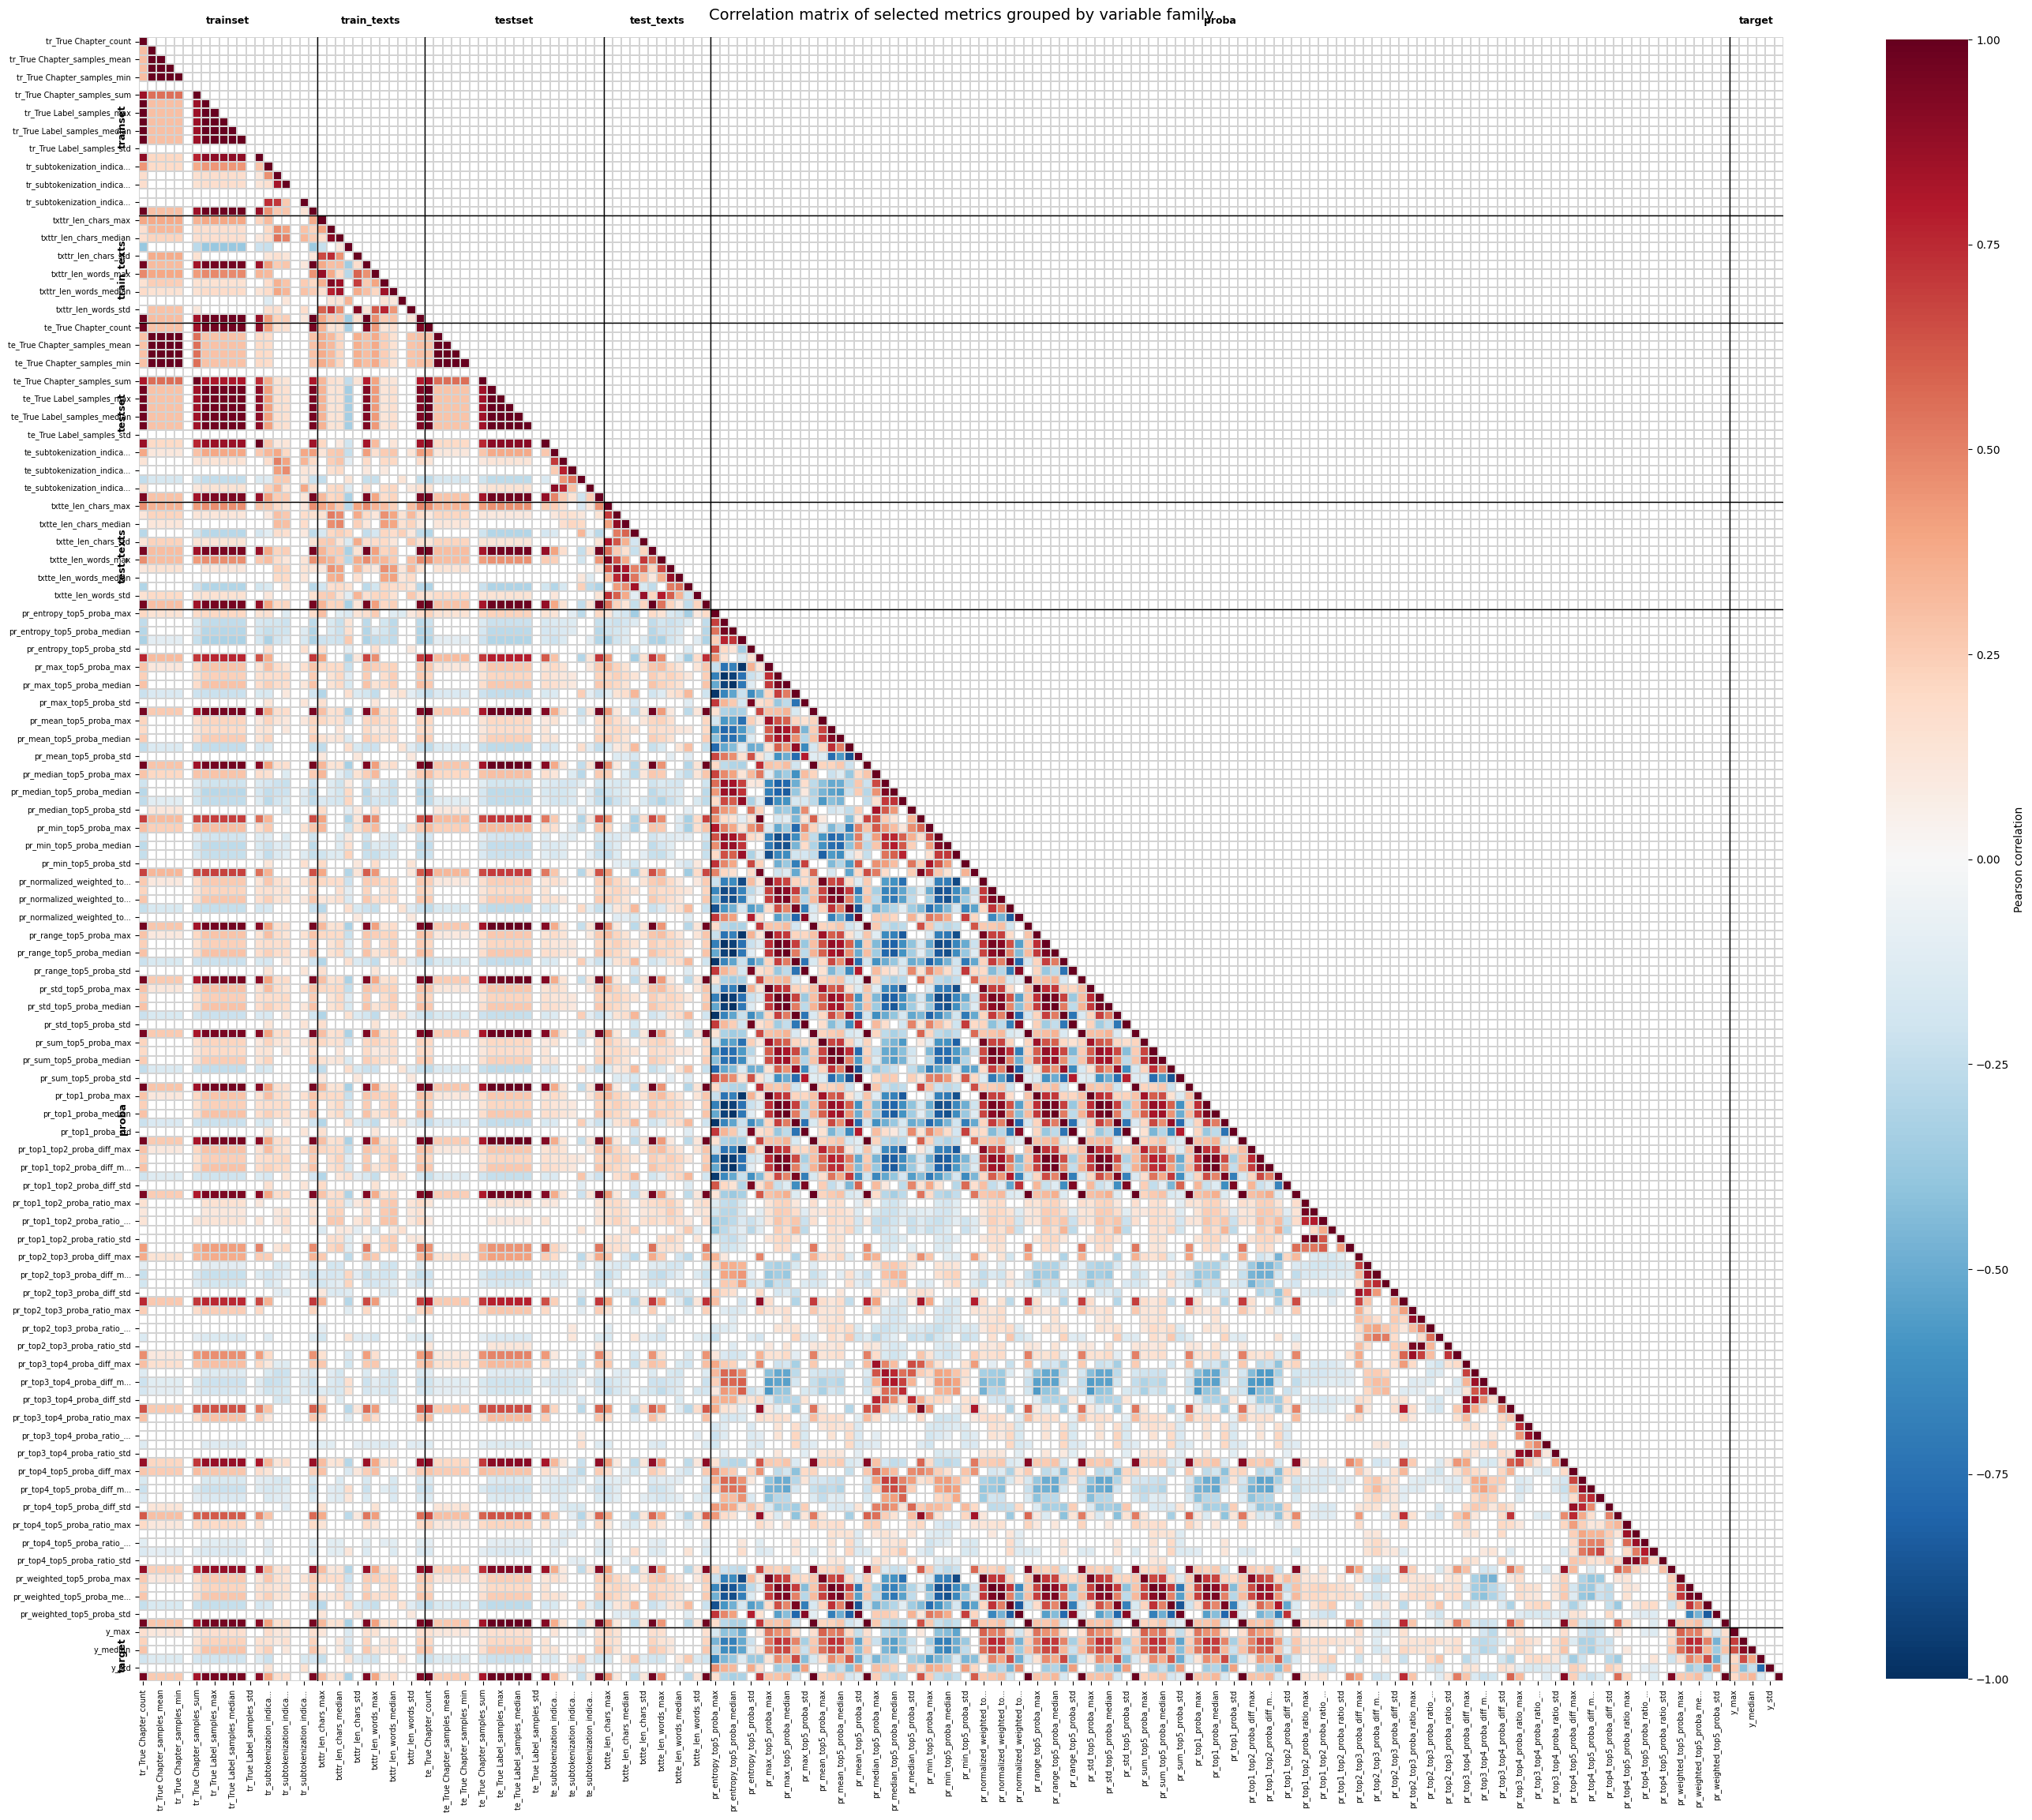

In [53]:
corr, meta = plot_grouped_correlation_matrix(
    df=HS04_merged_,
    method="pearson",
    min_abs_corr=0.10,              # opcional: deja en blanco correlaciones muy chicas
    show_upper_triangle=False,      # mejor para legibilidad
    annotate=False,                 # con 200 vars conviene no anotar
    title="Correlation matrix of selected metrics grouped by variable family",
    savepath="corr_grouped_full.png",
    dpi=300
)

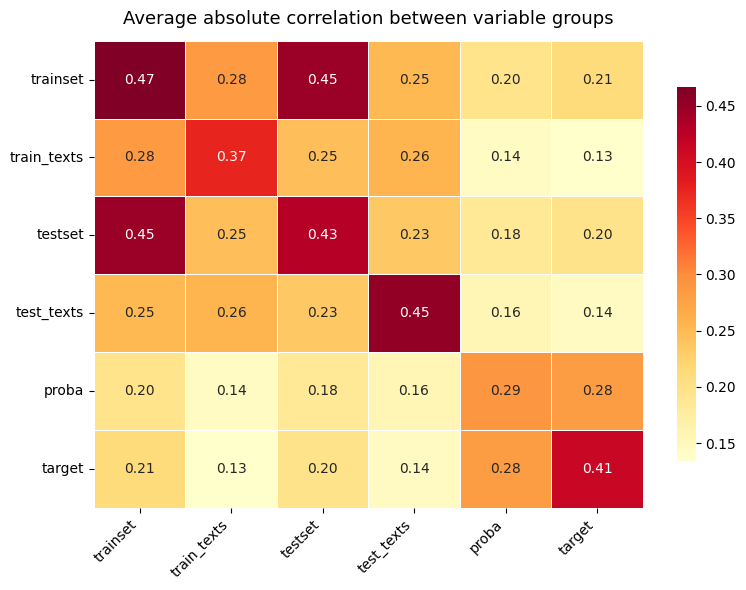

In [50]:
summary = plot_group_summary_matrix(
    df=HS04_merged_,
    method="pearson",
    summary_stat="mean_abs",   # muy útil para resumen ejecutivo
    annotate=True,
    title="Average absolute correlation between variable groups",
    savepath="corr_group_summary.png",
    dpi=300
)

### Feature relevance

As with have many numeric variables, to take into account, it is necessary to evaluate their relevance in order to successful prediction.

The possible targets are all related with true topN and prediction score:

    - pred_score, sum or mean
    - true_top1, sum or mean
    - true_top3, sum or mean

Mean values provide an indicator regardless the amount of samples in the testset.

pred_score mean is selected for now

#### Error helpers

In [32]:
#!pip uninstall -y numpy matplotlib shap

In [33]:
#!pip install --no-cache-dir numpy matplotlib shap

In [34]:
target_col = "pred_score_mean"

# para separar columnas
def split_feature_groups(df):
    cols = df.columns.tolist()

    id_cols = [c for c in cols if c in ["True Label", "True Chapter"]]

    performance_related = [
        c for c in cols
        if c.startswith("pred_score_") or c.startswith("true_top")
    ]

    train_related = [
        c for c in cols
        if c.endswith("_trainset")
        or "GOODS_DESCRIPTION_" in c
    ]

    test_related = [
        c for c in cols
        if c.endswith("_testset")
        or c.startswith("Description_len_")
    ]

    proba_related = [
        c for c in cols
        if (
            c.startswith("Proba Top")
            or c.startswith("top1_")
            or c.startswith("top2_")
            or c.startswith("top3_")
            or c.startswith("top4_")
            or c.startswith("top5_")
            or c.startswith("sum_top5_")
            or c.startswith("mean_top5_")
            or c.startswith("std_top5_")
            or c.startswith("max_top5_")
            or c.startswith("min_top5_")
            or c.startswith("range_top5_")
            or c.startswith("median_top5_")
            or c.startswith("entropy_top5_")
            or c.startswith("normalized_entropy_top5_")
            or c.startswith("weighted_top5_")
            or c.startswith("normalized_weighted_top5_")
        )
    ]

    return {
        "id_cols": sorted(set(id_cols)),
        "performance_related": sorted(set(performance_related)),
        "train_related": sorted(set(train_related)),
        "test_related": sorted(set(test_related)),
        "proba_related": sorted(set(proba_related)),
    }


# datasets leakage-safe
def build_feature_sets(df, target_col="pred_score_mean"):
    groups = split_feature_groups(df)

    # columnas numéricas / bool útiles
    numeric_bool_cols = df.select_dtypes(include=[np.number, "bool"]).columns.tolist()

    # excluir target de los features
    base_exclude = set(groups["id_cols"]) | {target_col}

    # excluir toda performance excepto target
    perf_exclude = set(groups["performance_related"]) - {target_col}

    # 1) análisis estructural: sin probas
    structural_features = [
        c for c in numeric_bool_cols
        if c not in base_exclude
        and c not in perf_exclude
        and c not in groups["proba_related"]
    ]

    # 2) análisis diagnóstico: incluye probas, excluye performance directa
    diagnostic_features = [
        c for c in numeric_bool_cols
        if c not in base_exclude
        and c not in perf_exclude
    ]

    return {
        "groups": groups,
        "structural_features": structural_features,
        "diagnostic_features": diagnostic_features,
    }

# Entrenamiento con XGBoost + CV
from xgboost import XGBRegressor
from sklearn.model_selection import RepeatedKFold, cross_validate
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def evaluate_xgb_cv(X, y, random_state=42):
    model = XGBRegressor(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,
        reg_lambda=1.0,
        min_child_weight=5,
        objective="reg:squarederror",
        random_state=random_state,
        n_jobs=-1
    )

    cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=random_state)

    scoring = {
        "r2": "r2",
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
    }

    cv_results = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_estimator=True,
        n_jobs=1
    )

    summary = {
        "r2_mean": np.mean(cv_results["test_r2"]),
        "r2_std": np.std(cv_results["test_r2"]),
        "mae_mean": -np.mean(cv_results["test_mae"]),
        "mae_std": np.std(-cv_results["test_mae"]),
        "rmse_mean": -np.mean(cv_results["test_rmse"]),
        "rmse_std": np.std(-cv_results["test_rmse"]),
    }

    return summary, cv_results


# Fit final + SHAP
import shap
import matplotlib.pyplot as plt

def fit_xgb_and_shap(X, y, random_state=42):
    model = XGBRegressor(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,
        reg_lambda=1.0,
        min_child_weight=5,
        objective="reg:squarederror",
        random_state=random_state,
        n_jobs=-1
    )

    model.fit(X, y)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    shap_importance = pd.DataFrame({
        "feature": X.columns,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0)
    }).sort_values("mean_abs_shap", ascending=False)

    return model, explainer, shap_values, shap_importance


# Importancia por grupo de variables
def assign_group(feature_name, groups):
    if feature_name in groups["train_related"]:
        return "train_related"
    elif feature_name in groups["test_related"]:
        return "test_related"
    elif feature_name in groups["proba_related"]:
        return "proba_related"
    elif feature_name in groups["performance_related"]:
        return "performance_related"
    else:
        return "other"

def shap_group_importance(shap_importance, groups):
    out = shap_importance.copy()
    out["group"] = out["feature"].apply(lambda x: assign_group(x, groups))
    group_imp = (
        out.groupby("group", as_index=False)["mean_abs_shap"]
        .sum()
        .sort_values("mean_abs_shap", ascending=False)
    )
    group_imp["share"] = group_imp["mean_abs_shap"] / group_imp["mean_abs_shap"].sum()
    return group_imp, out


# Filtro de variables con alta correlacion
from sklearn.feature_selection import mutual_info_regression

def correlation_mi_filter(
    X,
    y,
    corr_threshold=0.90,
    random_state=42,
    discrete_features="auto"
):
    """
    Remove highly correlated features using mutual information with target
    to decide which feature to keep in each correlated pair/group.

    Parameters
    ----------
    X : pd.DataFrame
        Feature matrix with numeric/bool columns only.
    y : pd.Series or np.ndarray
        Target variable.
    corr_threshold : float
        Absolute correlation threshold above which two features are considered redundant.
    random_state : int
        Random state for mutual_info_regression.
    discrete_features : 'auto' or array-like
        Passed to mutual_info_regression.

    Returns
    -------
    kept_features : list
        Selected features to keep.
    removed_features : list
        Removed features.
    mi_scores : pd.Series
        Mutual information scores by feature.
    corr_matrix : pd.DataFrame
        Absolute correlation matrix.
    decisions : pd.DataFrame
        Audit table with decisions made.
    """
    X = X.copy()

    # Ensure bool -> int for MI / corr robustness
    bool_cols = X.select_dtypes(include=["bool"]).columns
    if len(bool_cols) > 0:
        X[bool_cols] = X[bool_cols].astype(int)

    # Keep only numeric columns
    X = X.select_dtypes(include=[np.number])

    # Drop constant columns
    nunique = X.nunique(dropna=False)
    constant_cols = nunique[nunique <= 1].index.tolist()
    if constant_cols:
        X = X.drop(columns=constant_cols)

    # Fill missing values if any
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median(numeric_only=True))

    # Mutual information
    mi = mutual_info_regression(
        X,
        y,
        discrete_features=discrete_features,
        random_state=random_state
    )
    mi_scores = pd.Series(mi, index=X.columns).sort_values(ascending=False)

    # Absolute correlation matrix
    corr_matrix = X.corr().abs()

    # Upper triangle
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    removed = set()
    decisions = []

    cols = upper.columns.tolist()

    for col in cols:
        if col in removed:
            continue

        correlated_with_col = upper.index[upper[col] > corr_threshold].tolist()

        for other in correlated_with_col:
            if other in removed or col in removed:
                continue

            mi_col = mi_scores[col]
            mi_other = mi_scores[other]

            if mi_col >= mi_other:
                removed.add(other)
                decisions.append({
                    "kept": col,
                    "removed": other,
                    "corr": corr_matrix.loc[other, col],
                    "mi_kept": mi_col,
                    "mi_removed": mi_other
                })
            else:
                removed.add(col)
                decisions.append({
                    "kept": other,
                    "removed": col,
                    "corr": corr_matrix.loc[other, col],
                    "mi_kept": mi_other,
                    "mi_removed": mi_col
                })
                break

    removed_features = sorted(list(removed))
    kept_features = [c for c in X.columns if c not in removed]

    decisions = pd.DataFrame(decisions).sort_values(
        by=["corr", "mi_kept"], ascending=[False, False]
    )

    return kept_features, removed_features, mi_scores, corr_matrix, decisions

Dejamos solo las etiquetas presentes en el set de test

In [36]:
HS04_merged_ = HS04_merged.loc[HS04_merged['True Label_count_testset']>=1]

In [37]:
analysis = build_feature_sets(HS04_merged_, target_col="pred_score_mean")
groups = analysis["groups"]

y = HS04_merged_["pred_score_mean"]

In [38]:
y.value_counts(dropna=False)

pred_score_mean
5.000000    142
0.000000     63
4.000000     42
3.000000     27
2.000000     18
           ... 
2.700000      1
4.880000      1
4.238095      1
4.304348      1
3.076923      1
Name: count, Length: 102, dtype: int64

#### Structural model

Train & Test

Structural model CV:


{'r2_mean': np.float64(0.04330609501377726),
 'r2_std': np.float64(0.11399922703977887),
 'mae_mean': np.float64(1.298998408096135),
 'mae_std': np.float64(0.07553200207097728),
 'rmse_mean': np.float64(1.637782083819382),
 'rmse_std': np.float64(0.09144706700294855)}


Top SHAP features - structural


,feature,mean_abs_shap
9,GOODS_DESCRIPTION_len_chars_std,0.195890
13,subtokenization_indicator_max_trainset,0.178998
5,GOODS_DESCRIPTION_len_words_max,0.097930
7,GOODS_DESCRIPTION_len_chars_mean,0.093424
18,True Chapter_samples_sum_testset,0.088549
14,subtokenization_indicator_std_trainset,0.079676
25,Description_len_chars_std,0.070890
11,subtokenization_indicator_mean_trainset,0.067867
8,GOODS_DESCRIPTION_len_chars_max,0.065392
26,subtokenization_indicator_min_testset,0.047427



Group importance - structural


,group,mean_abs_shap,share
1,train_related,0.932313,0.654598
0,test_related,0.491940,0.345402


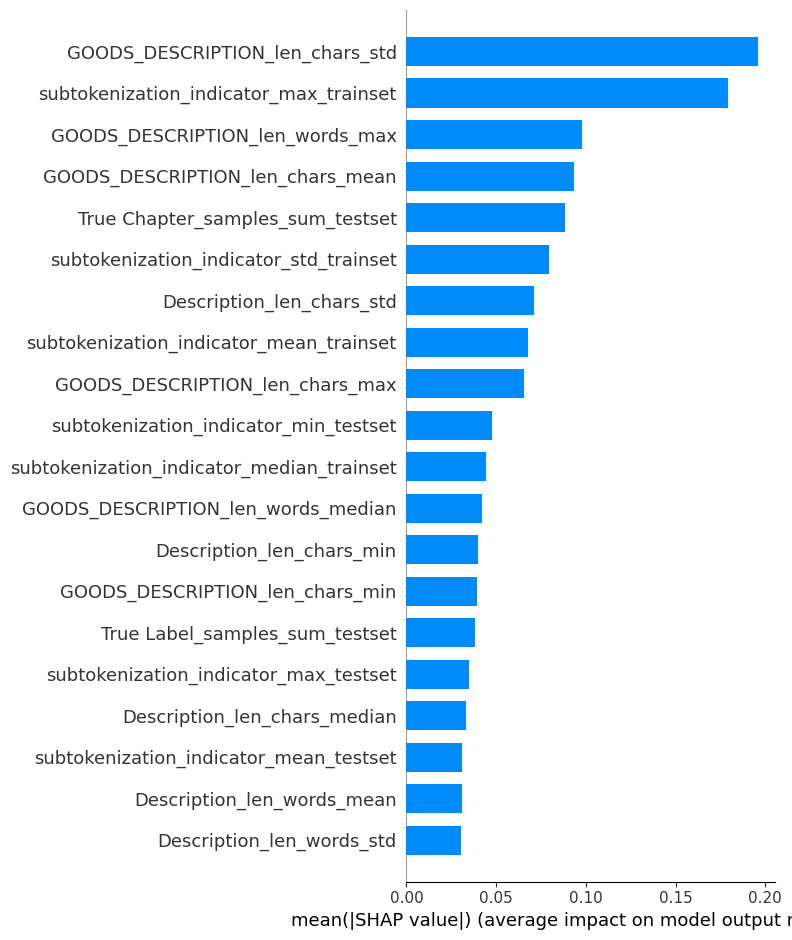

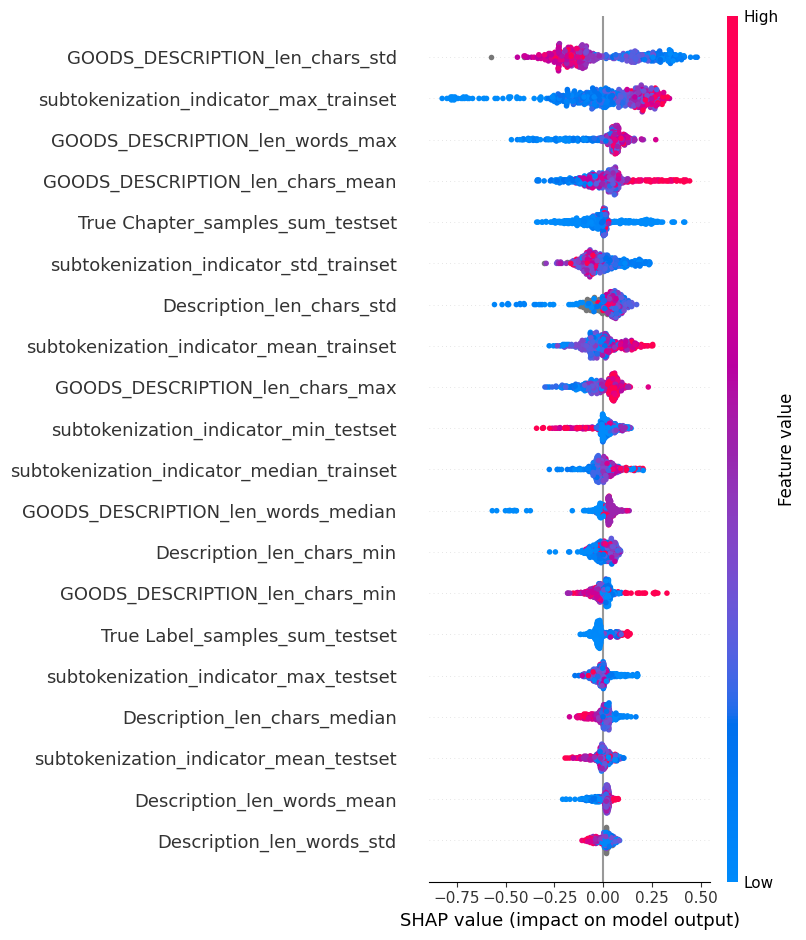

In [25]:
X_struct = HS04_merged_[analysis["structural_features"]].copy()

# X_struct = X_struct[[c for c in X_struct.columns if c.endswith(("_mean", "_std", "_median"))]]
kept_struct, removed_struct, mi_struct, corr_struct, decisions_struct = correlation_mi_filter(
    X_struct,
    y,
    corr_threshold=0.9,
    random_state=42
)

X_struct = X_struct[kept_struct].copy()

summary_struct, cv_struct = evaluate_xgb_cv(X_struct, y)
print("Structural model CV:")
display(summary_struct)

model_struct, explainer_struct, shap_vals_struct, shap_imp_struct = fit_xgb_and_shap(X_struct, y)
group_imp_struct, shap_imp_struct_labeled = shap_group_importance(shap_imp_struct, groups)

print("\nTop SHAP features - structural")
display(shap_imp_struct.head(20))

print("\nGroup importance - structural")
display(group_imp_struct)

shap.summary_plot(shap_vals_struct, X_struct, plot_type="bar")
shap.summary_plot(shap_vals_struct, X_struct)

Train only

Structural model CV:


{'r2_mean': np.float64(0.06782872622397312),
 'r2_std': np.float64(0.07828612228323754),
 'mae_mean': np.float64(1.2955080827031082),
 'mae_std': np.float64(0.07429027485641719),
 'rmse_mean': np.float64(1.619273626319955),
 'rmse_std': np.float64(0.08629560904022325)}


Top SHAP features - structural


,feature,mean_abs_shap
0,True Label_samples_sum_trainset,0.343478
8,subtokenization_indicator_median_trainset,0.124861
10,subtokenization_indicator_std_trainset,0.111290
4,True Chapter_samples_min_trainset,0.103298
9,subtokenization_indicator_max_trainset,0.087710
7,subtokenization_indicator_mean_trainset,0.084639
3,True Chapter_samples_sum_trainset,0.067047
1,True Label_samples_max_trainset,0.053720
6,subtokenization_indicator_min_trainset,0.000695
2,True Label_samples_std_trainset,0.000000



Group importance - structural


,group,mean_abs_shap,share
0,train_related,0.976738,1.0


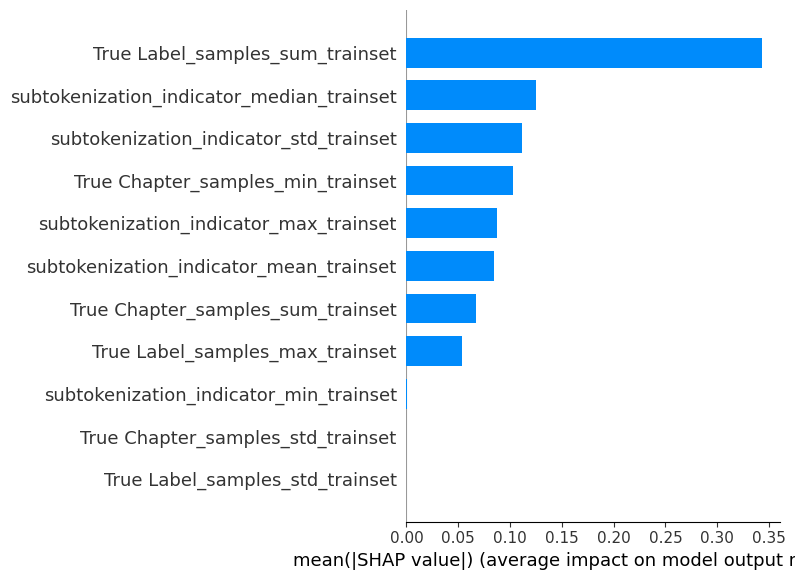

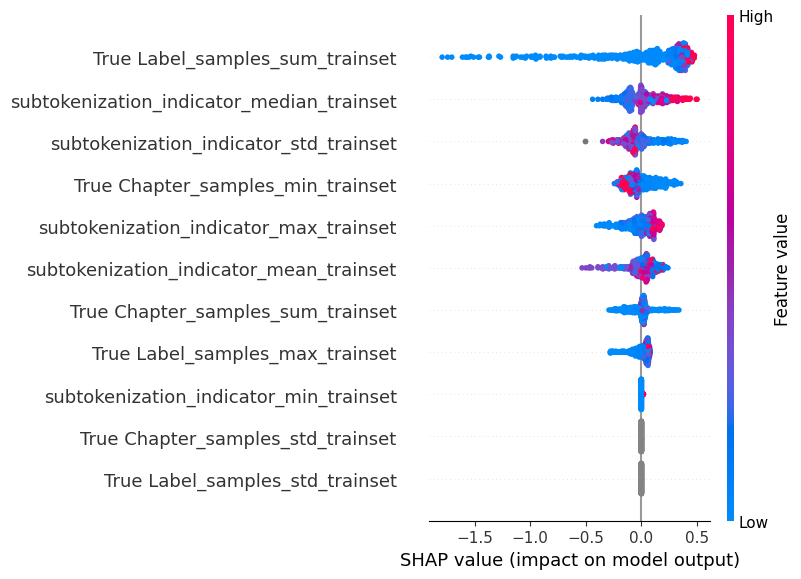

In [26]:
X_struct = HS04_merged_[analysis["structural_features"]].copy()

X_struct =  X_struct.filter(like='_trainset', axis=1)

# X_struct = X_struct[[c for c in X_struct.columns if c.endswith(("_mean", "_std", "_median"))]]
kept_struct, removed_struct, mi_struct, corr_struct, decisions_struct = correlation_mi_filter(
    X_struct,
    y,
    corr_threshold=0.95,
    random_state=42
)

X_struct = X_struct[kept_struct].copy()

summary_struct, cv_struct = evaluate_xgb_cv(X_struct, y)
print("Structural model CV:")
display(summary_struct)

model_struct, explainer_struct, shap_vals_struct, shap_imp_struct = fit_xgb_and_shap(X_struct, y)
group_imp_struct, shap_imp_struct_labeled = shap_group_importance(shap_imp_struct, groups)

print("\nTop SHAP features - structural")
display(shap_imp_struct.head(20))

print("\nGroup importance - structural")
display(group_imp_struct)

shap.summary_plot(shap_vals_struct, X_struct, plot_type="bar")
shap.summary_plot(shap_vals_struct, X_struct)

Structural model CV:


{'r2_mean': np.float64(-0.13475517575921697),
 'r2_std': np.float64(0.10331163581174832),
 'mae_mean': np.float64(1.4133613863051053),
 'mae_std': np.float64(0.0754886034830889),
 'rmse_mean': np.float64(1.7855115571463438),
 'rmse_std': np.float64(0.08192964448774769)}


Top SHAP features - structural


,feature,mean_abs_shap
0,True Chapter_count_testset,0.156725
3,True Chapter_samples_sum_testset,0.122712
10,subtokenization_indicator_std_testset,0.106564
4,True Chapter_samples_min_testset,0.100220
6,subtokenization_indicator_min_testset,0.083040
9,subtokenization_indicator_max_testset,0.069003
8,subtokenization_indicator_median_testset,0.058386
7,subtokenization_indicator_mean_testset,0.047795
1,True Label_samples_sum_testset,0.021025
2,True Label_samples_std_testset,0.000000



Group importance - structural


,group,mean_abs_shap,share
0,test_related,0.765471,1.0


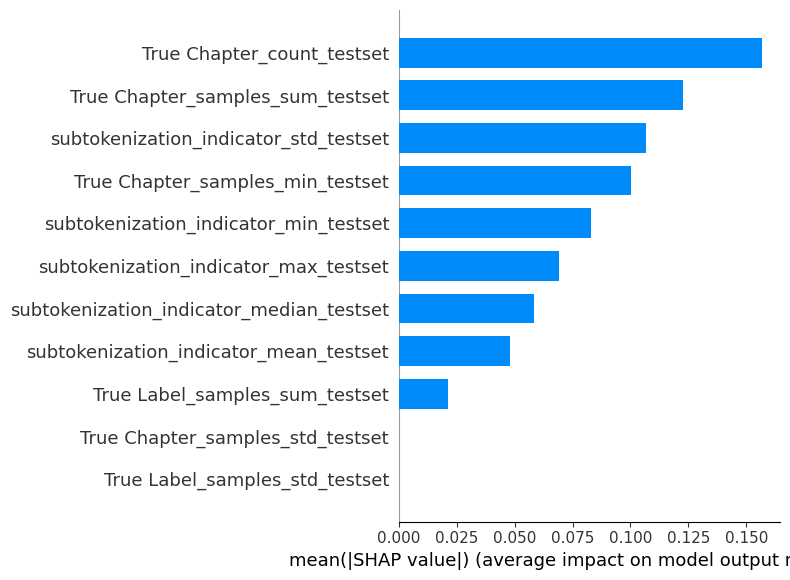

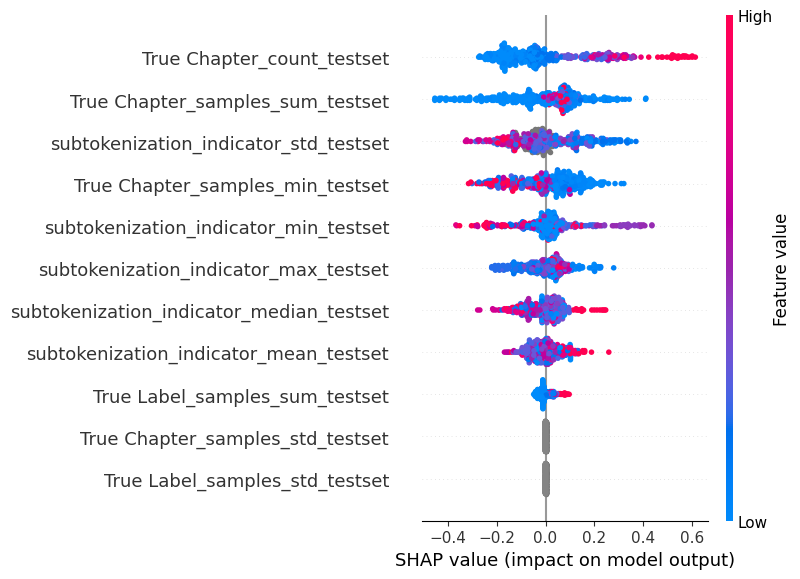

In [27]:
X_struct = HS04_merged_[analysis["structural_features"]].copy()

X_struct =  X_struct.filter(like='_testset', axis=1)

# X_struct = X_struct[[c for c in X_struct.columns if c.endswith(("_mean", "_std", "_median"))]]
kept_struct, removed_struct, mi_struct, corr_struct, decisions_struct = correlation_mi_filter(
    X_struct,
    y,
    corr_threshold=0.95,
    random_state=42
)

X_struct = X_struct[kept_struct].copy()

summary_struct, cv_struct = evaluate_xgb_cv(X_struct, y)
print("Structural model CV:")
display(summary_struct)

model_struct, explainer_struct, shap_vals_struct, shap_imp_struct = fit_xgb_and_shap(X_struct, y)
group_imp_struct, shap_imp_struct_labeled = shap_group_importance(shap_imp_struct, groups)

print("\nTop SHAP features - structural")
display(shap_imp_struct.head(20))

print("\nGroup importance - structural")
display(group_imp_struct)

shap.summary_plot(shap_vals_struct, X_struct, plot_type="bar")
shap.summary_plot(shap_vals_struct, X_struct)

#### Diagnostic model

In [28]:
analysis["diagnostic_features"]

['True Label_count_trainset',
 'True Chapter_count_trainset',
 'True Label_samples_sum_trainset',
 'True Label_samples_min_trainset',
 'True Label_samples_mean_trainset',
 'True Label_samples_median_trainset',
 'True Label_samples_max_trainset',
 'True Label_samples_std_trainset',
 'True Chapter_samples_sum_trainset',
 'True Chapter_samples_min_trainset',
 'True Chapter_samples_mean_trainset',
 'True Chapter_samples_median_trainset',
 'True Chapter_samples_max_trainset',
 'True Chapter_samples_std_trainset',
 'GOODS_DESCRIPTION_len_words_sum',
 'GOODS_DESCRIPTION_len_words_min',
 'GOODS_DESCRIPTION_len_words_mean',
 'GOODS_DESCRIPTION_len_words_median',
 'GOODS_DESCRIPTION_len_words_max',
 'GOODS_DESCRIPTION_len_words_std',
 'GOODS_DESCRIPTION_len_chars_sum',
 'GOODS_DESCRIPTION_len_chars_min',
 'GOODS_DESCRIPTION_len_chars_mean',
 'GOODS_DESCRIPTION_len_chars_median',
 'GOODS_DESCRIPTION_len_chars_max',
 'GOODS_DESCRIPTION_len_chars_std',
 'subtokenization_indicator_sum_trainset',
 's

Diagnostic model CV:


{'r2_mean': np.float64(0.3259072900943002),
 'r2_std': np.float64(0.09904437148567397),
 'mae_mean': np.float64(1.0039043132035135),
 'mae_std': np.float64(0.08239601322958451),
 'rmse_mean': np.float64(1.3743435101352028),
 'rmse_std': np.float64(0.10740436676070508)}


Top SHAP features - diagnostic


,feature,mean_abs_shap
104,normalized_weighted_top5_proba_median,0.379643
95,range_top5_proba_mean,0.218610
101,normalized_entropy_top5_median,0.090308
89,mean_top5_proba_max,0.068294
16,subtokenization_indicator_max_trainset,0.056148
21,Proba Top2_max,0.051843
88,mean_top5_proba_mean,0.049389
25,Proba Top4_mean,0.044023
10,GOODS_DESCRIPTION_len_chars_median,0.037069
75,top4_top5_proba_diff_min,0.036646



Group importance - diagnostic


,group,mean_abs_shap,share
0,proba_related,1.536039,0.798019
2,train_related,0.259128,0.134625
1,test_related,0.129649,0.067357


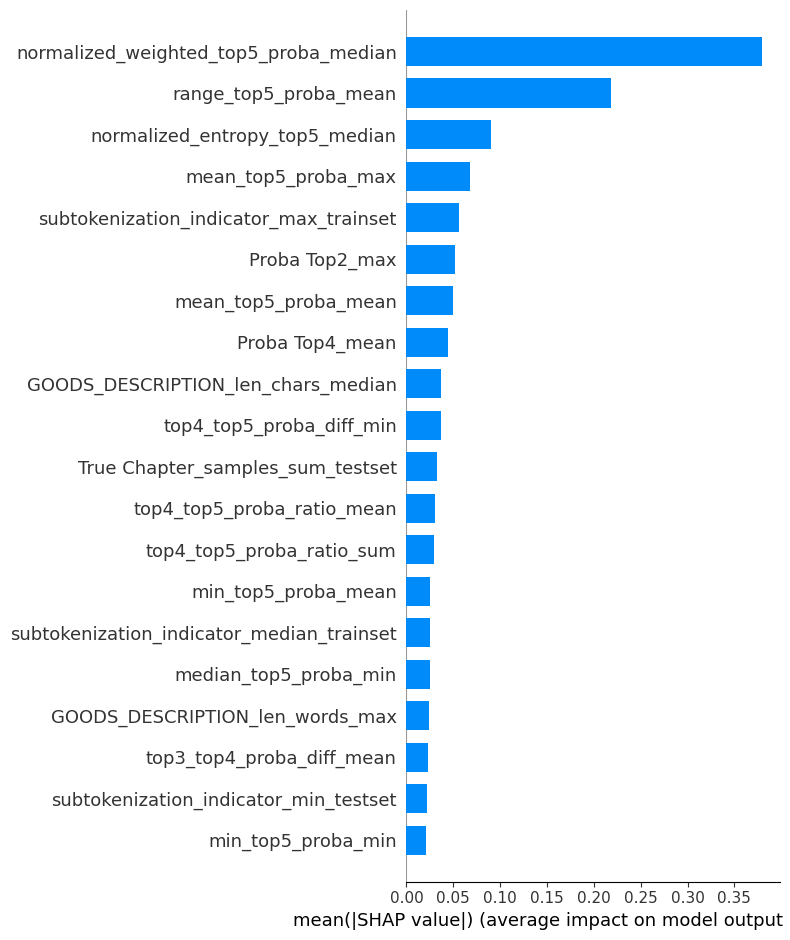

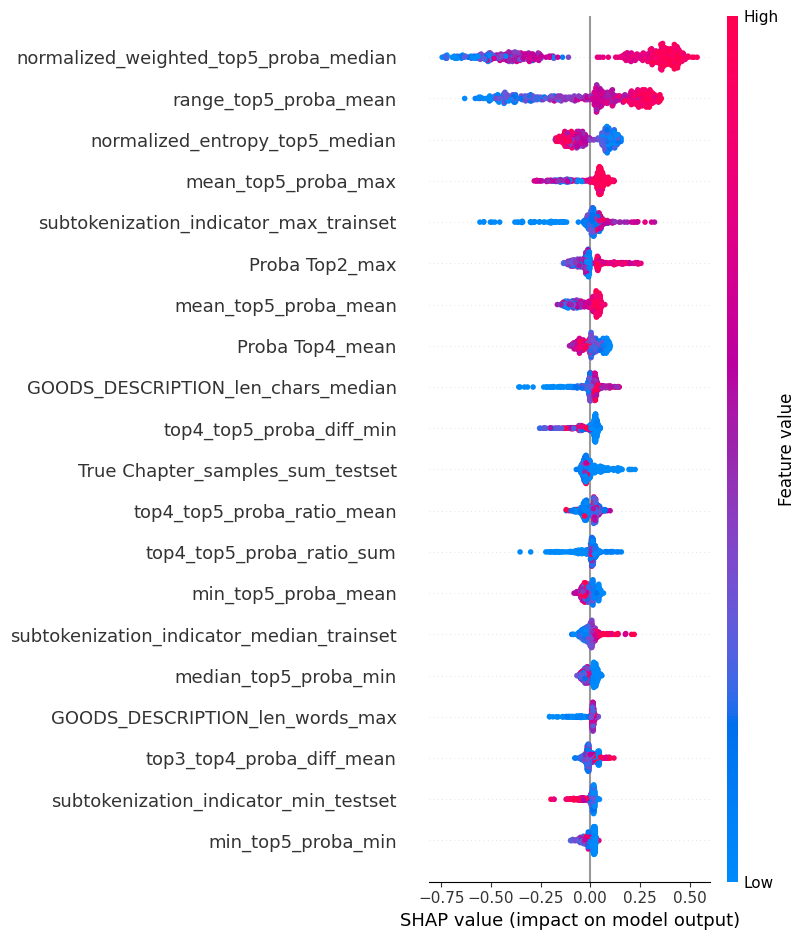

In [29]:
X_diag = HS04_merged_[analysis["diagnostic_features"]].copy()

kept_diag, removed_diag, mi_diag, corr_diag, decisions_diag = correlation_mi_filter(
    X_diag,
    y,
    corr_threshold=0.95,
    random_state=42
)

X_diag = X_diag[kept_diag].copy()

summary_diag, cv_diag = evaluate_xgb_cv(X_diag, y)
print("Diagnostic model CV:")
display(summary_diag)

model_diag, explainer_diag, shap_vals_diag, shap_imp_diag = fit_xgb_and_shap(X_diag, y)
group_imp_diag, shap_imp_diag_labeled = shap_group_importance(shap_imp_diag, groups)

print("\nTop SHAP features - diagnostic")
display(shap_imp_diag.head(20))

print("\nGroup importance - diagnostic")
display(group_imp_diag)

shap.summary_plot(shap_vals_diag, X_diag, plot_type="bar")
shap.summary_plot(shap_vals_diag, X_diag)

In [30]:
X_diag

,True Label_samples_std_trainset,True Chapter_samples_max_trainset,True Chapter_samples_std_trainset,GOODS_DESCRIPTION_len_words_min,GOODS_DESCRIPTION_len_words_mean,GOODS_DESCRIPTION_len_words_median,GOODS_DESCRIPTION_len_words_max,GOODS_DESCRIPTION_len_words_std,GOODS_DESCRIPTION_len_chars_min,GOODS_DESCRIPTION_len_chars_mean,...,range_top5_proba_mean,median_top5_proba_min,median_top5_proba_mean,median_top5_proba_max,normalized_entropy_top5_sum,normalized_entropy_top5_min,normalized_entropy_top5_median,normalized_entropy_top5_std,weighted_top5_proba_std,normalized_weighted_top5_proba_median
2,NaN,128,NaN,1,1.000000,1.0,1,NaN,4,4.000000,...,0.185151,0.040946,0.040946,0.040946,0.775124,0.775124,0.775124,NaN,NaN,0.098501
8,0.0,289,0.0,1,6.223301,6.0,14,3.071290,8,39.402913,...,0.562196,0.001461,0.045442,0.089423,0.973897,0.041151,0.486949,0.630454,2.012895,0.235156
11,0.0,289,0.0,2,3.324324,3.0,5,0.883618,10,22.378378,...,0.322621,0.037860,0.037860,0.037860,0.650021,0.650021,0.650021,NaN,NaN,0.148612
13,0.0,289,0.0,1,3.133333,2.0,10,2.325838,6,18.200000,...,0.599317,0.026150,0.026150,0.026150,0.498373,0.498373,0.498373,NaN,NaN,0.256265
22,0.0,1219,0.0,1,3.307190,3.0,9,1.438571,4,21.104575,...,0.890198,0.000630,0.013152,0.025673,0.398200,0.036348,0.199100,0.230166,0.370510,0.314930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1120,0.0,3054,0.0,1,3.808824,3.0,14,1.911039,3,24.036765,...,0.812404,0.002059,0.016865,0.036972,0.982135,0.037653,0.188904,0.226955,0.284776,0.312331
1122,0.0,3054,0.0,1,4.818868,5.0,17,2.700523,4,25.977358,...,0.995622,0.000245,0.000355,0.000610,0.074265,0.009235,0.015513,0.004918,0.003770,0.332784
1123,0.0,3054,0.0,1,3.767442,3.0,9,1.974085,6,22.767442,...,0.436168,0.046936,0.046936,0.046936,0.603076,0.603076,0.603076,NaN,NaN,0.190086
1124,0.0,92,0.0,1,3.137255,3.0,13,2.366598,6,21.098039,...,0.580776,0.082582,0.082582,0.082582,0.611017,0.611017,0.611017,NaN,NaN,0.268163
